# Gaussian-Process Tuning of MPC Cost Weights from Recorded ROS2 Bags

This notebook optimizes MPC cost weights from recorded bag data using a Gaussian-process Bayesian optimization loop.

What it logs clearly:
- which bag is loaded
- how many messages and replay frames are extracted
- baseline score before optimization
- every random and GP-guided candidate
- the best-so-far objective
- the final parameter set written to disk

The goal is to minimize a replay-based objective built from tracking error, obstacle clearance, control effort, and smoothness.

In [3]:
# If needed in a fresh environment:
!pip install 'numpy<2.0' scipy scikit-learn pandas matplotlib


In [4]:
!pip install casadi

In [5]:
import os, sys, json, math, sqlite3, random, time
from dataclasses import replace
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message

try:
    from sensor_msgs_py import point_cloud2
except Exception:
    point_cloud2 = None

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm

REPO_ROOT = Path('/media/lorenzo/writable/Go2_navigation')
PKG_ROOT = REPO_ROOT / 'src' / 'a_star_mpc_planner'
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from a_star_mpc_planner.mpc_tracker import MPCConfig, MPCTracker


def log_section(title):
    print(f"\n{'=' * 80}\n{title}\n{'=' * 80}")


def log_step(msg):
    print(f"[GP-TUNE] {msg}")


def fmt_dict(d, keys):
    return ', '.join(f"{k}={d[k]}" for k in keys if k in d)

In [6]:
# BAG_DB3 = REPO_ROOT / 'bags_recordings' / '20260429_140328' / 'bag' / 'bag_0.db3'
PARAM_YAML = REPO_ROOT / 'src' / 'a_star_mpc_planner' / 'config' / 'planner_params.yaml'

# Discover bag DB3 files under the repository `bags_recordings` layout.
BAGS_ROOT = REPO_ROOT / 'bags_recordings'
def _find_bags(subdir: str):
    p = BAGS_ROOT / subdir
    if not p.exists() or not p.is_dir():
        return []
    # search recursively for any 'bag' folders containing bag_*.db3
    return sorted(p.glob('**/bag/bag_*.db3'))

BAG_OFFICE_FILES = _find_bags('office')
BAG_EMPTY_FILES = _find_bags('empty_world')
BAG_INFERENCE_FILES = _find_bags('inference')

TOPIC_POSE = '/go2/pose'
TOPIC_PATH = '/a_star/path'
TOPIC_LIDAR = '/lidar/points_filtered'

MAX_FRAMES = 180
LIDAR_STRIDE = 12
LIDAR_MAX_POINTS = 300

N_INIT = 20
N_BO_ITERS = 100
RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

assert PARAM_YAML.exists(), PARAM_YAML

log_section('Notebook setup')
log_step(f'Repository root: {REPO_ROOT}')
log_step(f'Planner config : {PARAM_YAML}')
log_step(f'Random seed    : {RANDOM_SEED}')
log_step(f'Frames limit   : {MAX_FRAMES} (lidar stride={LIDAR_STRIDE}, max points={LIDAR_MAX_POINTS})')
log_step(f'BayesOpt rounds: {N_INIT} random + {N_BO_ITERS} GP-guided iterations')
log_step(f'Office bag files found : {len(BAG_OFFICE_FILES)}')
log_step(f'Empty-world bag files  : {len(BAG_EMPTY_FILES)}')
log_step(f'Inference bag files    : {len(BAG_INFERENCE_FILES)}')


Notebook setup
[GP-TUNE] Repository root: /media/lorenzo/writable/Go2_navigation
[GP-TUNE] Planner config : /media/lorenzo/writable/Go2_navigation/src/a_star_mpc_planner/config/planner_params.yaml
[GP-TUNE] Random seed    : 7
[GP-TUNE] Frames limit   : 180 (lidar stride=12, max points=300)
[GP-TUNE] BayesOpt rounds: 20 random + 100 GP-guided iterations
[GP-TUNE] Office bag files found : 6
[GP-TUNE] Empty-world bag files  : 1
[GP-TUNE] Inference bag files    : 1


In [7]:
def yaw_from_quat(q):
    siny = 2.0 * (q.w * q.z + q.x * q.y)
    cosy = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return math.atan2(siny, cosy)


def wrap_pi(a):
    return math.atan2(math.sin(a), math.cos(a))


def load_topic_messages(db3_path, topic_name):
    con = sqlite3.connect(str(db3_path))
    cur = con.cursor()
    row = cur.execute('SELECT id, type FROM topics WHERE name=?', (topic_name,)).fetchone()
    if row is None:
        con.close()
        return []
    topic_id, type_name = row
    msg_type = get_message(type_name)
    rows = cur.execute('SELECT timestamp, data FROM messages WHERE topic_id=? ORDER BY timestamp ASC', (topic_id,)).fetchall()
    con.close()
    out = []
    for ts, raw in rows:
        out.append((ts * 1e-9, deserialize_message(raw, msg_type)))
    return out


def load_and_concat(db3_paths, topic_name):
    """Load messages for `topic_name` from a list of DB3 files and concatenate them.

    Returns a single list of (timestamp, message) sorted by timestamp.
    """
    out = []
    for p in db3_paths:
        if not Path(p).exists():
            continue
        out.extend(load_topic_messages(p, topic_name))
    # ensure chronological order across multiple bags
    out.sort(key=lambda x: x[0])
    return out


def pointcloud2_to_xy(msg, stride=10, max_points=300):
    if point_cloud2 is not None:
        pts = []
        for i, p in enumerate(point_cloud2.read_points(msg, field_names=('x','y','z'), skip_nans=True)):
            if i % stride != 0:
                continue
            pts.append((float(p[0]), float(p[1])))
            if len(pts) >= max_points:
                break
        return np.asarray(pts, dtype=np.float64) if pts else np.empty((0,2), dtype=np.float64)

    fields = {f.name: (f.offset, f.datatype) for f in msg.fields}
    if 'x' not in fields or 'y' not in fields:
        return np.empty((0,2), dtype=np.float64)
    ox, _ = fields['x']
    oy, _ = fields['y']
    step = msg.point_step
    n = msg.width * msg.height
    buf = memoryview(msg.data)
    pts = []
    for i in range(0, n, stride):
        base = i * step
        x = np.frombuffer(buf[base+ox:base+ox+4], dtype=np.float32, count=1)[0]
        y = np.frombuffer(buf[base+oy:base+oy+4], dtype=np.float32, count=1)[0]
        if np.isfinite(x) and np.isfinite(y):
            pts.append((float(x), float(y)))
        if len(pts) >= max_points:
            break
    return np.asarray(pts, dtype=np.float64) if pts else np.empty((0,2), dtype=np.float64)


In [8]:
log_section('Load recorded bag messages')
log_step(f'Reading topics: {TOPIC_POSE}, {TOPIC_PATH}, {TOPIC_LIDAR}')

# Use the inference run bag(s)
combined_bag_files = list(BAG_INFERENCE_FILES)
if len(combined_bag_files) == 0:
    log_step('No inference-specific bags found; searching all bag folders under bags_recordings/inference')
    combined_bag_files = sorted((BAGS_ROOT / 'inference').glob('**/bag/bag_*.db3'))

assert len(combined_bag_files) > 0, f'No inference bag files found under: {BAGS_ROOT / "inference"}'

poses = load_and_concat(combined_bag_files, TOPIC_POSE)
paths = load_and_concat(combined_bag_files, TOPIC_PATH)
lidars = load_and_concat(combined_bag_files, TOPIC_LIDAR)

log_step(f'Loaded poses  : {len(poses)} messages (from {len(combined_bag_files)} files)')
log_step(f'Loaded paths  : {len(paths)} messages (from {len(combined_bag_files)} files)')
log_step(f'Loaded lidars : {len(lidars)} messages (from {len(combined_bag_files)} files)')

assert len(poses) > 10 and len(paths) > 0 and len(lidars) > 0
log_step('Inference bag contents look valid for replay construction')


Load recorded bag messages
[GP-TUNE] Reading topics: /go2/pose, /a_star/path, /lidar/points_filtered
[GP-TUNE] Loaded poses  : 2739 messages (from 1 files)
[GP-TUNE] Loaded paths  : 129 messages (from 1 files)
[GP-TUNE] Loaded lidars : 1209 messages (from 1 files)
[GP-TUNE] Inference bag contents look valid for replay construction


In [9]:
log_section('Build replay frames from synchronized bag signals')

def build_replay_frames(poses, paths, lidars, max_frames=200, lidar_stride=12, lidar_max_points=300):
    frames = []
    p_idx = 0
    l_idx = 0
    latest_path = None
    latest_lidar = None
    lidar_cache = {}

    log_step(f'Constructing aligned samples with max_frames={max_frames}')

    for i in range(1, len(poses)-1):
        t_prev, m_prev = poses[i-1]
        t_cur, m_cur = poses[i]
        t_next, m_next = poses[i+1]

        while p_idx < len(paths) and paths[p_idx][0] <= t_cur:
            latest_path = paths[p_idx][1]
            p_idx += 1
        while l_idx < len(lidars) and lidars[l_idx][0] <= t_cur:
            latest_lidar = lidars[l_idx][1]
            l_idx += 1

        if latest_path is None or latest_lidar is None:
            continue

        dt = t_cur - t_prev
        if dt <= 1e-3 or dt > 0.5:
            continue

        x_prev, y_prev = float(m_prev.pose.position.x), float(m_prev.pose.position.y)
        x_cur, y_cur = float(m_cur.pose.position.x), float(m_cur.pose.position.y)
        x_next, y_next = float(m_next.pose.position.x), float(m_next.pose.position.y)

        yaw_prev = yaw_from_quat(m_prev.pose.orientation)
        yaw_cur = yaw_from_quat(m_cur.pose.orientation)
        yaw_next = yaw_from_quat(m_next.pose.orientation)

        vx = (x_cur - x_prev) / dt
        vy = (y_cur - y_prev) / dt
        wz = wrap_pi(yaw_cur - yaw_prev) / dt

        path_xyz = [(float(ps.pose.position.x), float(ps.pose.position.y), float(ps.pose.position.z)) for ps in latest_path.poses]
        if len(path_xyz) < 2:
            continue

        lid_id = id(latest_lidar)
        if lid_id not in lidar_cache:
            lidar_cache[lid_id] = pointcloud2_to_xy(latest_lidar, stride=lidar_stride, max_points=lidar_max_points)
        obs_xy = lidar_cache[lid_id]

        frames.append({
            't': t_cur,
            'state': np.array([x_cur, y_cur, yaw_cur, vx, vy, wz], dtype=np.float64),
            'next_state': np.array([x_next, y_next, yaw_next], dtype=np.float64),
            'path': path_xyz,
            'obs_xy': obs_xy,
        })

    if len(frames) > max_frames:
        idx = np.linspace(0, len(frames)-1, max_frames).astype(int)
        frames = [frames[k] for k in idx]

    return frames

frames = build_replay_frames(poses, paths, lidars, MAX_FRAMES, LIDAR_STRIDE, LIDAR_MAX_POINTS)
log_step(f'Replay frames constructed: {len(frames)}')
assert len(frames) >= 30
log_step('Replay set is large enough for GP optimization')


Build replay frames from synchronized bag signals
[GP-TUNE] Constructing aligned samples with max_frames=180
[GP-TUNE] Replay frames constructed: 180
[GP-TUNE] Replay set is large enough for GP optimization


In [10]:
import yaml
with open(PARAM_YAML, 'r') as f:
    base_yaml = yaml.safe_load(f)
ros_params = base_yaml['/**']['ros__parameters']

base_cfg = MPCConfig(
    N=int(ros_params['mpc_N']),
    dt=float(ros_params['mpc_dt']),
    tau_v=float(ros_params['mpc_tau_v']),
    tau_w=float(ros_params['mpc_tau_w']),
    vx_max=float(ros_params['mpc_vx_max']),
    vy_max=float(ros_params['mpc_vy_max']),
    omega_max=float(ros_params['mpc_omega_max']),
    v_ref=float(ros_params['mpc_v_ref']),
    Q_x=float(ros_params['mpc_Q_x']),
    Q_y=float(ros_params['mpc_Q_y']),
    Q_yaw=float(ros_params['mpc_Q_yaw']),
    Q_terminal=float(ros_params['mpc_Q_terminal']),
    R_vx=float(ros_params['mpc_R_vx']),
    R_vy=float(ros_params['mpc_R_vy']),
    R_omega=float(ros_params['mpc_R_omega']),
    R_jerk=float(ros_params['mpc_R_jerk']),
    W_obs_sigmoid=float(ros_params['mpc_W_obs_sigmoid']),
    obs_alpha=float(ros_params['mpc_obs_alpha']),
    obs_r=float(ros_params['mpc_obs_r']),
    max_obs_constraints=int(ros_params['mpc_max_obs_constraints']),
    obs_check_radius=float(ros_params['mpc_obs_check_radius']),
    max_iter=int(ros_params['mpc_max_iter']),
    warm_start=bool(ros_params['mpc_warm_start']),
)
base_cfg


MPCConfig(N=50, dt=0.1, tau_v=0.12, tau_w=0.1, vx_max=1.0, vy_max=0.5, omega_max=1.5, v_ref=0.5, Q_x=81.406819, Q_y=76.793851, Q_yaw=0.159859, Q_terminal=184.780052, R_vx=9.948168, R_vy=8.106174, R_omega=9.809461, R_jerk=2.684864, W_obs_sigmoid=4.830974, obs_alpha=13.438599, obs_r=0.098285, max_obs_constraints=12, obs_check_radius=3.0, max_iter=100, warm_start=True, print_level=0)

In [11]:
PARAM_BOUNDS = {
    'Q_x': (50.0, 500.0),
    'Q_y': (50.0, 500.0),
    'Q_yaw': (0.05, 15.0),
    'Q_terminal': (20.0, 300.0),
    'R_vx': (0.1, 3.0),
    'R_vy': (0.1, 3.0),
    'R_omega': (0.1, 3.0),
    'R_jerk': (0.1, 5.0),
    'W_obs_sigmoid': (50.0, 400.0),
    'obs_alpha': (1.0, 8.0),
    'obs_r': (0.35, 0.85),
}
PARAM_NAMES = list(PARAM_BOUNDS.keys())
LOW = np.array([PARAM_BOUNDS[k][0] for k in PARAM_NAMES], dtype=np.float64)
HIGH = np.array([PARAM_BOUNDS[k][1] for k in PARAM_NAMES], dtype=np.float64)

log_section('MPC parameter search space')
for name in PARAM_NAMES:
    lo, hi = PARAM_BOUNDS[name]
    log_step(f'{name:14s}: [{lo:.4f}, {hi:.4f}]')


def vec_to_param_dict(xvec):
    return {k: float(v) for k, v in zip(PARAM_NAMES, xvec)}


def make_cfg_from_vec(base, xvec):
    p = vec_to_param_dict(xvec)
    return replace(base, Q_x=p['Q_x'], Q_y=p['Q_y'], Q_yaw=p['Q_yaw'], Q_terminal=p['Q_terminal'],
                   R_vx=p['R_vx'], R_vy=p['R_vy'], R_omega=p['R_omega'], R_jerk=p['R_jerk'],
                   W_obs_sigmoid=p['W_obs_sigmoid'], obs_alpha=p['obs_alpha'], obs_r=p['obs_r'])


def min_obstacle_distance(pt_xy, obs_xy):
    if obs_xy is None or len(obs_xy) == 0:
        return np.inf
    return float(np.min(np.linalg.norm(obs_xy - pt_xy[None, :], axis=1)))


def evaluate_params(xvec, frames, base_cfg):
    cfg = make_cfg_from_vec(base_cfg, xvec)
    tracker = MPCTracker(config=cfg)

    J = 0.0
    n_fail = 0
    prev_u0 = None

    for fr in frames:
        state = fr['state']
        gt_next = fr['next_state']
        path = fr['path']
        obs = fr['obs_xy']

        res = tracker.solve(state, path, obstacle_points_2d=obs)
        if (not res.success) or (res.x_pred is None) or (len(res.x_pred) < 2):
            J += 25.0
            n_fail += 1
            continue

        pred_next = res.x_pred[1]
        e_pos = float(np.linalg.norm(pred_next[:2] - gt_next[:2]))
        e_yaw = abs(wrap_pi(float(pred_next[2] - gt_next[2])))

        u0 = res.u_opt[0] if res.u_opt is not None and len(res.u_opt) > 0 else np.zeros(3)
        u_norm = float(np.linalg.norm(u0))
        jerk = float(np.linalg.norm(u0 - prev_u0)) if prev_u0 is not None else 0.0
        prev_u0 = u0.copy()

        dmin = min_obstacle_distance(pred_next[:2], obs)
        obs_violation = max(0.0, cfg.obs_r - dmin)

        step_loss = (
            8.0 * (e_pos ** 2) +
            2.0 * (e_yaw ** 2) +
            0.2 * (u_norm ** 2) +
            0.6 * (jerk ** 2) +
            30.0 * (obs_violation ** 2) +
            0.002 * float(res.solve_time_ms)
        )

        if (not np.isfinite(step_loss)) or step_loss > 1e6:
            J += 50.0
            n_fail += 1
            continue

        J += step_loss

    n_total = max(1, len(frames))
    fail_ratio = n_fail / n_total
    J = J / n_total + 20.0 * fail_ratio
    return float(J), {'fail_ratio': float(fail_ratio), 'fail_count': int(n_fail)}


MPC parameter search space
[GP-TUNE] Q_x           : [50.0000, 500.0000]
[GP-TUNE] Q_y           : [50.0000, 500.0000]
[GP-TUNE] Q_yaw         : [0.0500, 15.0000]
[GP-TUNE] Q_terminal    : [20.0000, 300.0000]
[GP-TUNE] R_vx          : [0.1000, 3.0000]
[GP-TUNE] R_vy          : [0.1000, 3.0000]
[GP-TUNE] R_omega       : [0.1000, 3.0000]
[GP-TUNE] R_jerk        : [0.1000, 5.0000]
[GP-TUNE] W_obs_sigmoid : [50.0000, 400.0000]
[GP-TUNE] obs_alpha     : [1.0000, 8.0000]
[GP-TUNE] obs_r         : [0.3500, 0.8500]


In [12]:
log_section('Baseline score before optimization')
x0 = np.array([getattr(base_cfg, k) for k in PARAM_NAMES], dtype=np.float64)
log_step('Evaluating the starting MPC weights from planner_params.yaml')
J0, info0 = evaluate_params(x0, frames, base_cfg)
log_step(f'Baseline objective = {J0:.6f}')
log_step(f'Baseline failures   = {info0["fail_count"]} / {len(frames)} ({info0["fail_ratio"]:.1%})')
log_step('This baseline becomes the reference point for GP search')


Baseline score before optimization
[GP-TUNE] Evaluating the starting MPC weights from planner_params.yaml
[GP-TUNE] Baseline objective = 0.297179
[GP-TUNE] Baseline failures   = 0 / 180 (0.0%)
[GP-TUNE] This baseline becomes the reference point for GP search


In [13]:
PARAM_BOUNDS = {
    'Q_x': (50.0, 200.0),
    'Q_y': (50.0, 200.0),
    'Q_yaw': (0.0, 15.0),
    'Q_terminal': (50.0, 300.0),
    'R_vx': (0.1, 10.0),
    'R_vy': (0.1, 10.0),
    'R_omega': (0.1, 10.0),
    'R_jerk': (0.1, 5.0),
    'W_obs_sigmoid': (1.0, 500.0),
    'obs_alpha': (0.1, 15.0),
    'obs_r': (0.05, 1.0),
}
PARAM_NAMES = list(PARAM_BOUNDS.keys())
LOW = np.array([PARAM_BOUNDS[k][0] for k in PARAM_NAMES])
HIGH = np.array([PARAM_BOUNDS[k][1] for k in PARAM_NAMES])

# For scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
scaler.fit(np.vstack([LOW, HIGH]));

In [14]:
def fit_gp(X_train, y_train):
    """Fits a Gaussian Process Regressor to the training data."""
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.5, nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e2))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10,
        alpha=1e-2,
        normalize_y=True,
        random_state=RANDOM_SEED
    )
    gp.fit(X_train, y_train)
    return gp


def propose_next(gp, scaler):
    """Proposes the next sample point by maximizing the Expected Improvement acquisition function."""
    # Generate a large number of random samples in the normalized [0,1] space
    n_probes = 5000
    probes = np.random.rand(n_probes, scaler.n_features_in_)
    
    # Predict mean and std dev for the probes
    mu, std = gp.predict(probes, return_std=True)
    
    # Get the best observed objective so far (minimum)
    y_best = np.min(gp.y_train_)
    
    # Calculate Expected Improvement (EI)
    with np.errstate(divide='ignore'): # Ignore division by zero for probes with zero std
        imp = y_best - mu
        Z = imp / std
        ei = imp * norm.cdf(Z) + std * norm.pdf(Z)
        ei[std == 0.0] = 0.0

    # Find the probe that maximizes EI
    best_idx = np.argmax(ei)
    x_next_normalized = probes[best_idx]
    
    # Denormalize to get the actual parameter vector
    x_next = scaler.inverse_transform(x_next_normalized.reshape(1, -1)).flatten()
    
    # Return the next point and some diagnostics
    max_ei = float(ei[best_idx])
    pred_mu = float(mu[best_idx])
    pred_std = float(std[best_idx])
    
    return x_next, max_ei, pred_mu, pred_std


In [ ]:
log_section('Gaussian-process Bayesian optimization')
history = []
X = []
y = []

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.vstack([LOW, HIGH]))

log_step(f'Random initialization: {N_INIT} samples')
for i in range(N_INIT):
    x = LOW + np.random.rand(len(PARAM_NAMES)) * (HIGH - LOW)
    obj, info = evaluate_params(x, frames, base_cfg)
    X.append(x)
    y.append(obj)
    history.append({'iter': i, 'mode': 'random', 'objective': obj, **vec_to_param_dict(x), **info})
    log_step(f'[{i:02d}] random  obj={obj:.4f}  fail={info["fail_ratio"]:.1%}  params={fmt_dict(vec_to_param_dict(x), PARAM_NAMES[:4])}')

log_step(f'GP-guided search: {N_BO_ITERS} iterations')
for k in range(N_BO_ITERS):
    X_arr = np.asarray(X, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    Xn = scaler.transform(X_arr)

    gp = fit_gp(Xn, y_arr)
    x_next, ei, mu, std = propose_next(gp, scaler)
    obj, info = evaluate_params(x_next, frames, base_cfg)

    X.append(x_next)
    y.append(obj)
    history.append({'iter': N_INIT+k, 'mode': 'gp', 'objective': obj, 'ei': ei, 'mu': mu, 'std': std,
                    **vec_to_param_dict(x_next), **info})
    log_step(
        f'[{N_INIT+k:02d}] gp      obj={obj:.4f}  ei={ei:.4f}  '
        f'mu={mu:.4f}  std={std:.4f}  fail={info["fail_ratio"]:.1%}'
    )
    log_step('        ' + fmt_dict(vec_to_param_dict(x_next), PARAM_NAMES))

hist_df = pd.DataFrame(history)
log_step(f'Optimization complete: best objective so far = {hist_df["objective"].min():.6f}')
hist_df.sort_values('objective').head(10)


Gaussian-process Bayesian optimization
[GP-TUNE] Random initialization: 20 samples


CasADi - 2026-04-30 02:29:32 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:132]


[GP-TUNE] [00] random  obj=2.0940  fail=0.6%  params=Q_x=61.44624340609357, Q_y=166.9878188360172, Q_yaw=6.576138471613403, Q_terminal=230.8662944577353



Best parameter set and objective trace
[GP-TUNE] Best objective found = 0.596378
[GP-TUNE] Best parameters:
[GP-TUNE]   Q_x           : 81.406819
[GP-TUNE]   Q_y           : 76.793851
[GP-TUNE]   Q_yaw         : 0.159859
[GP-TUNE]   Q_terminal    : 184.780052
[GP-TUNE]   R_vx          : 9.948168
[GP-TUNE]   R_vy          : 8.106174
[GP-TUNE]   R_omega       : 9.809461
[GP-TUNE]   R_jerk        : 2.684864
[GP-TUNE]   W_obs_sigmoid : 4.830974
[GP-TUNE]   obs_alpha     : 13.438599
[GP-TUNE]   obs_r         : 0.098285


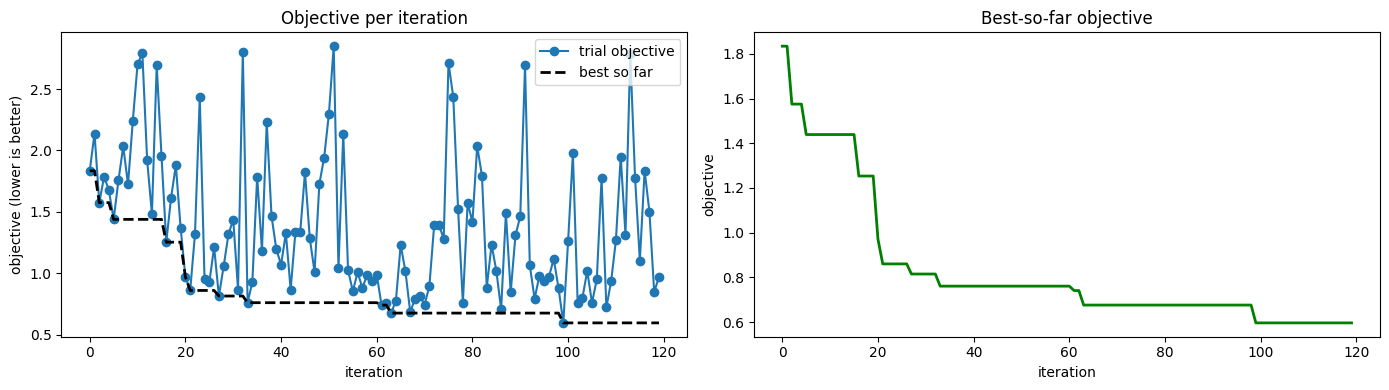

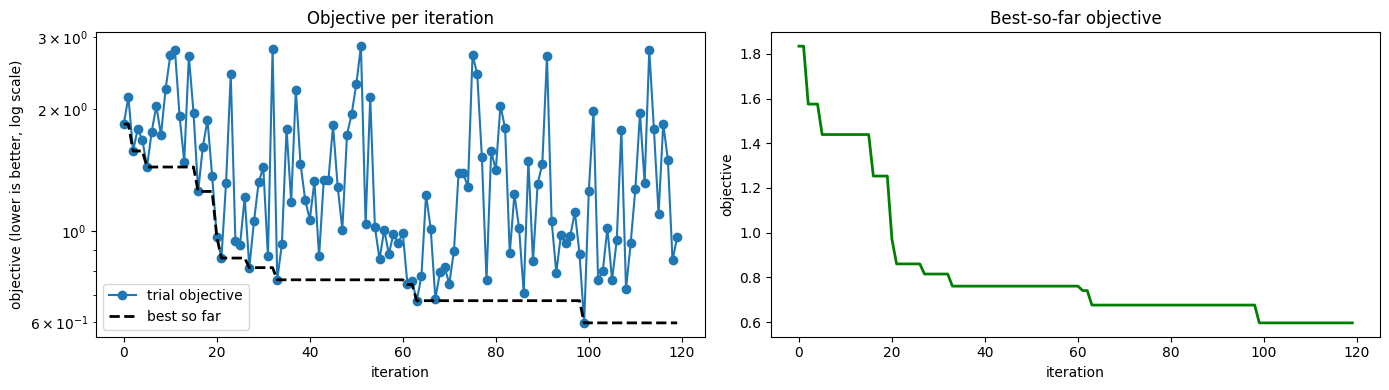

[GP-TUNE] Use the saved JSON/YAML-ready summary cell below to copy parameters into planner_params.yaml


In [ ]:
log_section('Best parameter set and objective trace')
best_idx = int(np.argmin(np.asarray(y)))
best_x = np.asarray(X)[best_idx]
best_obj = float(np.min(np.asarray(y)))
best_params = vec_to_param_dict(best_x)

log_step(f'Best objective found = {best_obj:.6f}')
log_step('Best parameters:')
for k in PARAM_NAMES:
    log_step(f'  {k:14s}: {best_params[k]:.6f}')

plot_df = hist_df.copy()
plot_df['best_so_far'] = plot_df['objective'].cummin()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(plot_df['iter'], plot_df['objective'], 'o-', label='trial objective')
ax[0].plot(plot_df['iter'], plot_df['best_so_far'], 'k--', lw=2, label='best so far')
ax[0].set_title('Objective per iteration')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('objective (lower is better)')
ax[0].legend()

ax[1].plot(plot_df['iter'], plot_df['best_so_far'], 'g-', lw=2)
ax[1].set_title('Best-so-far objective')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('objective')
plt.tight_layout()
plt.savefig('gp_optimization_trace_log1.pdf')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(plot_df['iter'], plot_df['objective'], 'o-', label='trial objective')
ax[0].plot(plot_df['iter'], plot_df['best_so_far'], 'k--', lw=2, label='best so far')
ax[0].set_title('Objective per iteration')
ax[0].set_xlabel('iteration')
ax[0].set_ylabel('objective (lower is better, log scale)')
ax[0].set_yscale('log')
ax[0].legend()

ax[1].plot(plot_df['iter'], plot_df['best_so_far'], 'g-', lw=2)
ax[1].set_title('Best-so-far objective')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('objective')
plt.tight_layout()
plt.savefig('gp_optimization_trace_log2.pdf')
plt.show()

log_step('Use the saved JSON/YAML-ready summary cell below to copy parameters into planner_params.yaml')

In [ ]:
log_section('Save optimization results')
out_dir = REPO_ROOT / 'bag_gp_tuning'
out_dir.mkdir(parents=True, exist_ok=True)

record = {
    'bag': str(combined_bag_files[0]) if len(combined_bag_files) > 0 else '',
    'frames_used': len(frames),
    'n_init': N_INIT,
    'n_bo_iters': N_BO_ITERS,
    'best_objective': best_obj,
    'best_params': best_params,
    'history': history,
}
with open(out_dir / 'gp_bag_tuning_history.json', 'w') as f:
    json.dump(record, f, indent=2)

key_map = {
    'Q_x': 'mpc_Q_x',
    'Q_y': 'mpc_Q_y',
    'Q_yaw': 'mpc_Q_yaw',
    'Q_terminal': 'mpc_Q_terminal',
    'R_vx': 'mpc_R_vx',
    'R_vy': 'mpc_R_vy',
    'R_omega': 'mpc_R_omega',
    'R_jerk': 'mpc_R_jerk',
    'W_obs_sigmoid': 'mpc_W_obs_sigmoid',
    'obs_alpha': 'mpc_obs_alpha',
    'obs_r': 'mpc_obs_r',
}

log_step(f'Saved history to: {out_dir / "gp_bag_tuning_history.json"}')
log_step('Copy the following into planner_params.yaml:')
for k in PARAM_NAMES:
    log_step(f'  {key_map[k]}: {best_params[k]:.6f}')


Save optimization results
[GP-TUNE] Saved history to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_bag_tuning_history.json
[GP-TUNE] Copy the following into planner_params.yaml:
[GP-TUNE]   mpc_Q_x: 81.406819
[GP-TUNE]   mpc_Q_y: 76.793851
[GP-TUNE]   mpc_Q_yaw: 0.159859
[GP-TUNE]   mpc_Q_terminal: 184.780052
[GP-TUNE]   mpc_R_vx: 9.948168
[GP-TUNE]   mpc_R_vy: 8.106174
[GP-TUNE]   mpc_R_omega: 9.809461
[GP-TUNE]   mpc_R_jerk: 2.684864
[GP-TUNE]   mpc_W_obs_sigmoid: 4.830974
[GP-TUNE]   mpc_obs_alpha: 13.438599
[GP-TUNE]   mpc_obs_r: 0.098285


In [29]:
# Post-optimization MPC cost-function plots
log_section('Post-optimization MPC cost-function plots')

def evaluate_params_detailed(xvec, frames, base_cfg):
    cfg = make_cfg_from_vec(base_cfg, xvec)
    tracker = MPCTracker(config=cfg)

    terms = {
        'tracking_xy': [],
        'tracking_yaw': [],
        'control_effort': [],
        'control_jerk': [],
        'obstacle': [],
        'solver_time': [],
        'penalty_fail': [],
        'step_total': [],
    }

    n_fail = 0
    prev_u0 = None

    for fr in frames:
        state = fr['state']
        gt_next = fr['next_state']
        path = fr['path']
        obs = fr['obs_xy']

        res = tracker.solve(state, path, obstacle_points_2d=obs)
        if (not res.success) or (res.x_pred is None) or (len(res.x_pred) < 2):
            fail_pen = 25.0
            terms['tracking_xy'].append(0.0)
            terms['tracking_yaw'].append(0.0)
            terms['control_effort'].append(0.0)
            terms['control_jerk'].append(0.0)
            terms['obstacle'].append(0.0)
            terms['solver_time'].append(0.0)
            terms['penalty_fail'].append(fail_pen)
            terms['step_total'].append(fail_pen)
            n_fail += 1
            continue

        pred_next = res.x_pred[1]
        e_pos = float(np.linalg.norm(pred_next[:2] - gt_next[:2]))
        e_yaw = abs(wrap_pi(float(pred_next[2] - gt_next[2])))

        u0 = res.u_opt[0] if res.u_opt is not None and len(res.u_opt) > 0 else np.zeros(3)
        u_norm = float(np.linalg.norm(u0))
        jerk = float(np.linalg.norm(u0 - prev_u0)) if prev_u0 is not None else 0.0
        prev_u0 = u0.copy()

        dmin = min_obstacle_distance(pred_next[:2], obs)
        obs_violation = max(0.0, cfg.obs_r - dmin)

        c_xy = 8.0 * (e_pos ** 2)
        c_yaw = 2.0 * (e_yaw ** 2)
        c_u = 0.2 * (u_norm ** 2)
        c_j = 0.6 * (jerk ** 2)
        c_obs = 30.0 * (obs_violation ** 2)
        c_t = 0.002 * float(res.solve_time_ms)

        step_loss = c_xy + c_yaw + c_u + c_j + c_obs + c_t

        if (not np.isfinite(step_loss)) or step_loss > 1e6:
            fail_pen = 50.0
            terms['tracking_xy'].append(0.0)
            terms['tracking_yaw'].append(0.0)
            terms['control_effort'].append(0.0)
            terms['control_jerk'].append(0.0)
            terms['obstacle'].append(0.0)
            terms['solver_time'].append(0.0)
            terms['penalty_fail'].append(fail_pen)
            terms['step_total'].append(fail_pen)
            n_fail += 1
            continue

        terms['tracking_xy'].append(c_xy)
        terms['tracking_yaw'].append(c_yaw)
        terms['control_effort'].append(c_u)
        terms['control_jerk'].append(c_j)
        terms['obstacle'].append(c_obs)
        terms['solver_time'].append(c_t)
        terms['penalty_fail'].append(0.0)
        terms['step_total'].append(step_loss)

    n_total = max(1, len(frames))
    fail_ratio = n_fail / n_total

    means = {k: float(np.mean(v)) for k, v in terms.items()}
    objective = means['step_total'] + means['penalty_fail'] + 20.0 * fail_ratio

    return {
        'objective': float(objective),
        'fail_ratio': float(fail_ratio),
        'means': means,
        'series': {k: np.asarray(v, dtype=np.float64) for k, v in terms.items()},
    }



Post-optimization MPC cost-function plots


In [ ]:
base_det = evaluate_params_detailed(x0, frames, base_cfg)
best_det = evaluate_params_detailed(best_x, frames, base_cfg)

log_step(f"Baseline detailed objective : {base_det['objective']:.6f}")
log_step(f"Optimized detailed objective: {best_det['objective']:.6f}")
log_step(f"Baseline fail ratio         : {base_det['fail_ratio']:.2%}")
log_step(f"Optimized fail ratio        : {best_det['fail_ratio']:.2%}")


[GP-TUNE] Baseline detailed objective : 2.641292
[GP-TUNE] Optimized detailed objective: 0.595709
[GP-TUNE] Baseline fail ratio         : 0.56%
[GP-TUNE] Optimized fail ratio        : 0.00%


In [ ]:
# 1) MPC cost-term decomposition (baseline vs optimized)
# term_order = [
#     'tracking_xy', 'tracking_yaw', 'control_effort',
#     'control_jerk', 'obstacle', 'solver_time', 'penalty_fail'
# ]
# term_labels = {
#     'tracking_xy': 'tracking_xy',
#     'tracking_yaw': 'tracking_yaw',
#     'control_effort': 'control_effort',
#     'control_jerk': 'control_jerk',
#     'obstacle': 'obstacle',
#     'solver_time': 'solver_time',
#     'penalty_fail': 'fail_penalty',
# }

# base_vals = [base_det['means'][k] for k in term_order]
# best_vals = [best_det['means'][k] for k in term_order]

# fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# x = np.arange(len(term_order))
# w = 0.38
# ax[0].bar(x - w/2, base_vals, width=w, label='baseline')
# ax[0].bar(x + w/2, best_vals, width=w, label='optimized')
# ax[0].set_xticks(x)
# ax[0].set_xticklabels([term_labels[k] for k in term_order], rotation=35, ha='right')
# ax[0].set_ylabel('mean contribution per frame', fontsize=15)
# ax[0].set_title('MPC objective term decomposition', fontsize=15)
# ax[0].legend()

import numpy as np
import matplotlib.pyplot as plt

best_params = saved_record['best_params']
param_order = list(best_params.keys())
param_names = slice_params  # ['Q_x', 'Q_y', 'R_jerk', 'W_obs_sigmoid', 'obs_r']

def run_mpc(params_dict):
    xvec = np.array([params_dict[k] for k in param_order], dtype=float)
    return evaluate_params_detailed(xvec, frames, base_cfg)

fig, ax = plt.subplots(figsize=(10, 6))

for p in param_names:
    if p not in best_params:
        continue

    base_val = float(best_params[p])
    if base_val == 0.0:
        sweep = np.linspace(-1.0, 1.0, 15)
    else:
        sweep = np.linspace(0.5 * base_val, 1.5 * base_val, 15)

    costs = []
    for val in sweep:
        test_params = best_params.copy()
        test_params[p] = float(val)
        result = run_mpc(test_params)
        costs.append(result['objective'])

    ax.plot(sweep, costs, marker='o', label=p)

ax.set_xlabel('Parameter value', fontsize=15)
ax.set_ylabel('Objective function', fontsize=15)
ax.set_title('Sensitivity Analysis of MPC Weights', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

# Objective + fail ratio summary
summary_names = ['objective', 'fail_ratio']
base_s = [base_det['objective'], base_det['fail_ratio']]
best_s = [best_det['objective'], best_det['fail_ratio']]
xs = np.arange(len(summary_names))

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(xs - w/2, base_s, width=w, label='baseline')
ax2.bar(xs + w/2, best_s, width=w, label='BO tuned')
ax2.set_xticks(xs)
ax2.set_xticklabels(summary_names, fontsize=15)
ax2.set_title('Global optimization metrics', fontsize=15)
ax2.legend()

plt.tight_layout()
plt.show()

# 2) Frame-wise step cost evolution
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(base_det['series']['step_total'], label='baseline cost', alpha=0.8)
ax.plot(best_det['series']['step_total'], label='BO tuned cost', alpha=0.8)
ax.set_xlabel('replay frame index', fontsize=15)
ax.set_ylabel('cost', fontsize=15)
ax.set_title('Per-frame MPC step cost after optimization', fontsize=15)
ax.legend()
plt.tight_layout()
plt.savefig('MPC_objective_function.pdf')
plt.show()

# 2) Frame-wise step cost evolution
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(base_det['series']['step_total'], label='baseline cost', alpha=0.8)
ax.plot(best_det['series']['step_total'], label='BO tuned cost', alpha=0.8)
ax.set_xlabel('replay frame index', fontsize=15)
ax.set_ylabel('cost (log scale)', fontsize=15)
ax.set_title('Per-frame MPC step cost after optimization', fontsize=15)
ax.legend()
plt.tight_layout()
ax.set_yscale('log')
plt.savefig('MPC_objective_function_log.pdf')

plt.show()

CasADi - 2026-04-30 02:08:16 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:114]


In [ ]:
# # 3) Local cost-function slices around optimized parameters

# slice_params = ['Q_x', 'Q_y', 'R_jerk', 'W_obs_sigmoid', 'obs_r']
# n_grid = 18

# fig, axes = plt.subplots(2, 3, figsize=(16, 8))
# axes = axes.flatten()

# for idx, pname in enumerate(slice_params):
#     ax = axes[idx]
#     lo, hi = PARAM_BOUNDS[pname]
#     xs = np.linspace(lo, hi, n_grid)
#     ys = []
#     pidx = PARAM_NAMES.index(pname)

#     for xv in xs:
#         xprobe = best_x.copy()
#         xprobe[pidx] = xv
#         obj, _ = evaluate_params(xprobe, frames, base_cfg)
#         ys.append(obj)

#     ys = np.asarray(ys)
#     ax.plot(xs, ys, '-o', ms=3)
#     ax.axvline(best_x[pidx], color='r', linestyle='--', label='best')
#     ax.set_title(f'Cost slice: {pname}')
#     ax.set_xlabel(pname)
#     ax.set_ylabel('objective')
#     ax.legend()

# # Optional 2D slice for interaction insight
# ax2 = axes[-1]
# p1, p2 = 'Q_x', 'W_obs_sigmoid'
# i1, i2 = PARAM_NAMES.index(p1), PARAM_NAMES.index(p2)
# x1 = np.linspace(*PARAM_BOUNDS[p1], 12)
# x2 = np.linspace(*PARAM_BOUNDS[p2], 12)
# Z = np.zeros((len(x1), len(x2)))
# for i, a in enumerate(x1):
#     for j, b in enumerate(x2):
#         xprobe = best_x.copy()
#         xprobe[i1] = a
#         xprobe[i2] = b
#         obj, _ = evaluate_params(xprobe, frames, base_cfg)
#         Z[i, j] = obj

# im = ax2.imshow(
#     Z.T, origin='lower', aspect='auto',
#     extent=[x1.min(), x1.max(), x2.min(), x2.max()]
# )
# ax2.scatter([best_x[i1]], [best_x[i2]], c='r', s=50, marker='x', label='best')
# ax2.set_xlabel(p1)
# ax2.set_ylabel(p2)
# ax2.set_title('2D local objective slice')
# ax2.legend(loc='best')
# fig.colorbar(im, ax=ax2, label='objective')

# for k in range(len(slice_params), len(axes)-1):
#     axes[k].axis('off')

# plt.tight_layout()
# plt.show()


# GP Surrogate and Trajectory Analysis

Visualize the Gaussian Process surrogate model and compare baseline vs optimized MPC trajectories.

In [10]:
log_section('Load saved GP training data')

# Load the optimization history from previous run
history_file = REPO_ROOT / 'bag_gp_tuning' / 'gp_bag_tuning_history.json'
assert history_file.exists(), f'History file not found: {history_file}'

with open(history_file, 'r') as f:
    saved_record = json.load(f)

saved_history = saved_record['history']
log_step(f'Loaded {len(saved_history)} optimization samples from {history_file}')

# Reconstruct X and y arrays
X = []
y = []
for record in saved_history:
    xvec = np.array([record[pname] for pname in PARAM_NAMES], dtype=np.float64)
    X.append(xvec)
    y.append(float(record['objective']))

X = np.asarray(X)
y = np.asarray(y)
log_step(f'Reconstructed X shape: {X.shape}, y shape: {y.shape}')

# Recreate the scaler and fit final GP
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.vstack([LOW, HIGH]))
Xn = scaler.transform(X)
gp_final = fit_gp(Xn, y)

# Extract best params
best_obj = float(saved_record['best_objective'])
best_params = saved_record['best_params']
best_x = np.array([best_params[pname] for pname in PARAM_NAMES], dtype=np.float64)

log_step(f'Best objective from history: {best_obj:.6f}')
log_step('X, y, scaler, and gp_final are now ready for visualization')


Load saved GP training data
[GP-TUNE] Loaded 120 optimization samples from /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_bag_tuning_history.json
[GP-TUNE] Reconstructed X shape: (120, 11), y shape: (120,)
[GP-TUNE] Best objective from history: 0.596378
[GP-TUNE] X, y, scaler, and gp_final are now ready for visualization



GP Surrogate Model Visualization
[GP-TUNE] Fitted GP surrogate on all collected samples


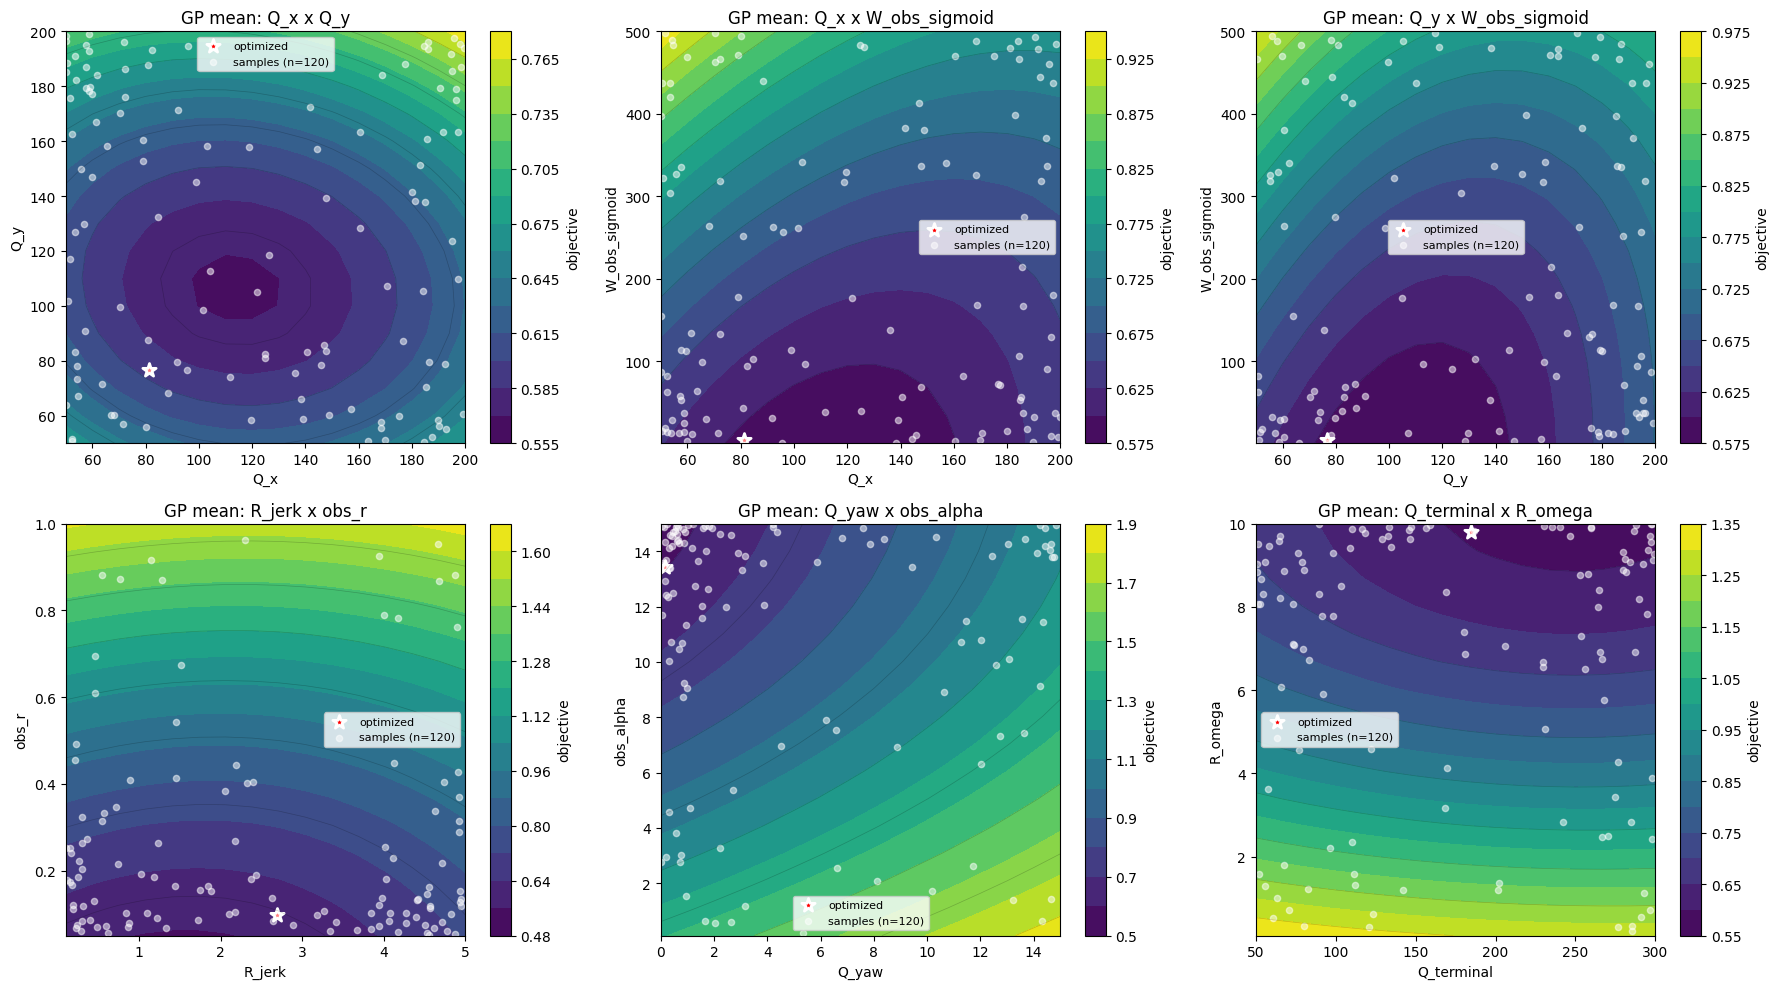

[GP-TUNE] GP surrogate 2D sections plotted with uncertainty estimation


In [11]:
log_section('GP Surrogate Model Visualization')

# Fit final GP on all data
X_arr = np.asarray(X, dtype=np.float64)
y_arr = np.asarray(y, dtype=np.float64)
Xn = scaler.transform(X_arr)
gp_final = fit_gp(Xn, y_arr)

log_step('Fitted GP surrogate on all collected samples')

# 2D slices with uncertainty bands
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

param_pairs = [
    ('Q_x', 'Q_y'),
    ('Q_x', 'W_obs_sigmoid'),
    ('Q_y', 'W_obs_sigmoid'),
    ('R_jerk', 'obs_r'),
    ('Q_yaw', 'obs_alpha'),
    ('Q_terminal', 'R_omega'),
]

for idx, (p1, p2) in enumerate(param_pairs):
    ax = axes[idx]
    i1, i2 = PARAM_NAMES.index(p1), PARAM_NAMES.index(p2)
    
    x1 = np.linspace(*PARAM_BOUNDS[p1], 16)
    x2 = np.linspace(*PARAM_BOUNDS[p2], 16)
    X1, X2 = np.meshgrid(x1, x2)
    Z_mu = np.zeros_like(X1)
    Z_std = np.zeros_like(X1)
    
    for i, a in enumerate(x1):
        for j, b in enumerate(x2):
            xprobe = best_x.copy()
            xprobe[i1] = a
            xprobe[i2] = b
            xprobe_n = scaler.transform(xprobe.reshape(1, -1))
            mu, std = gp_final.predict(xprobe_n, return_std=True)
            Z_mu[j, i] = mu[0]
            Z_std[j, i] = std[0]
    
    # Plot mean with uncertainty bands
    im = ax.contourf(X1, X2, Z_mu, levels=15, cmap='viridis')
    ax.contour(X1, X2, Z_mu, levels=8, colors='k', alpha=0.2, linewidths=0.5)
    
    # Mark best point
    ax.scatter([best_x[i1]], [best_x[i2]], c='r', s=100, marker='*', edgecolors='white', linewidths=2, label='optimized')
    
    # Mark collected samples
    samples_p1 = X_arr[:, i1]
    samples_p2 = X_arr[:, i2]
    ax.scatter(samples_p1, samples_p2, c='white', s=20, alpha=0.5, label=f'samples (n={len(X_arr)})')
    
    ax.set_xlabel(p1)
    ax.set_ylabel(p2)
    ax.set_title(f'GP mean: {p1} x {p2}')
    ax.legend(fontsize=8, loc='best')
    fig.colorbar(im, ax=ax, label='objective')

plt.tight_layout()
plt.show()

log_step('GP surrogate 2D sections plotted with uncertainty estimation')


GP posterior marginals per parameter (with log-scale, jitter, and saving)
[GP-TUNE] Using 120 observed samples for overlay


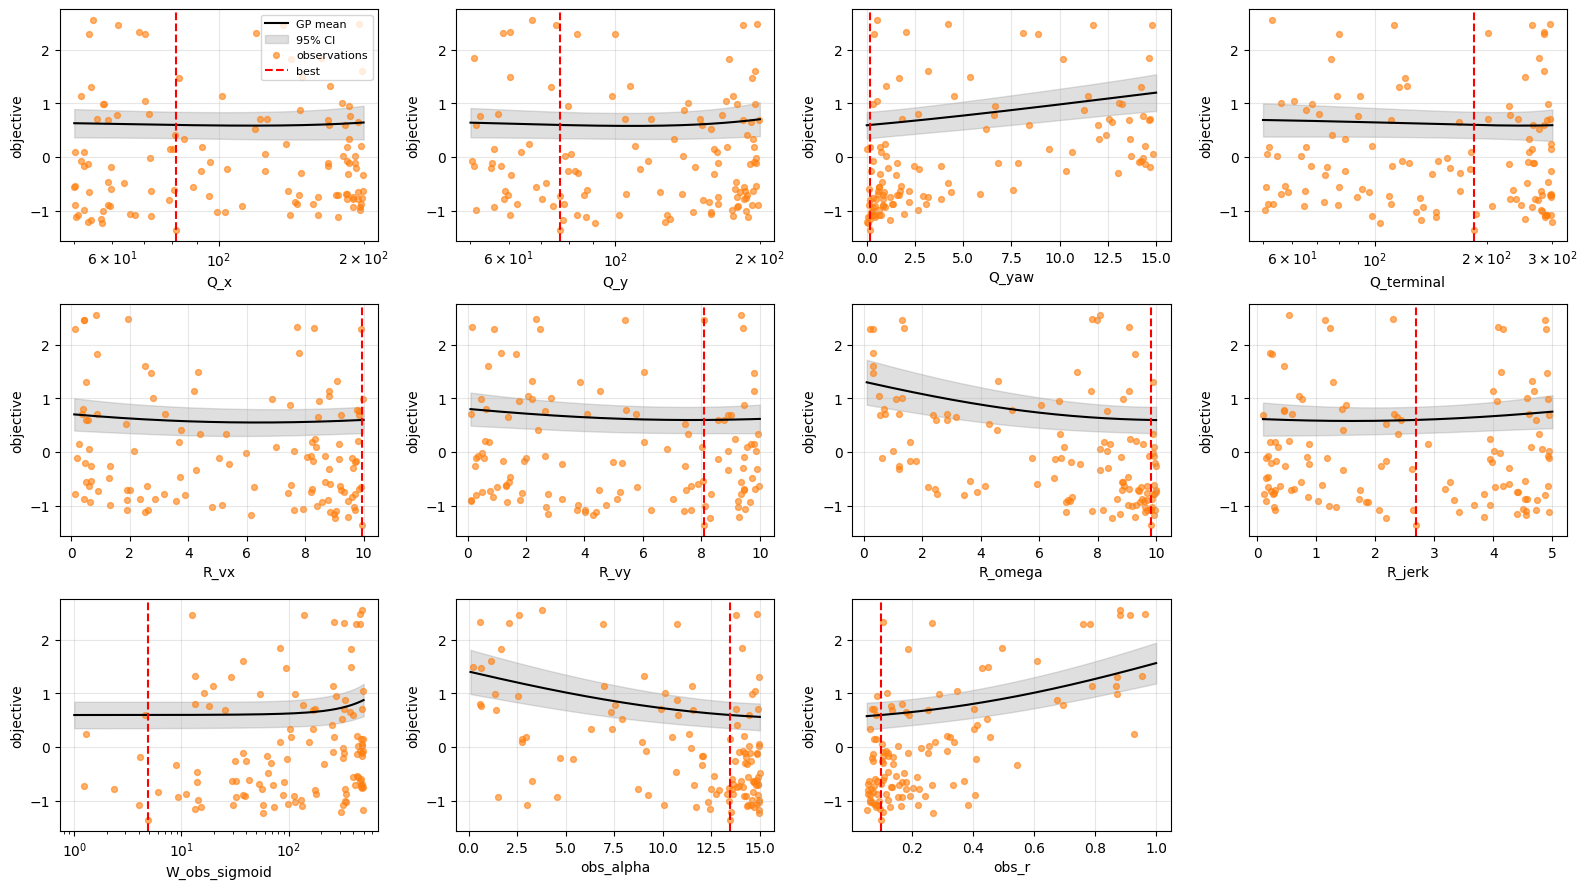

[GP-TUNE] Plotted GP posterior marginals and saved figures to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/gp_marginals/gp_marginals_combined.png


In [12]:
log_section('GP posterior marginals per parameter (with log-scale, jitter, and saving)')

# Ensure X_arr exists
if 'X_arr' not in globals():
    X_arr = np.asarray(X, dtype=np.float64)

# Choose observed samples source robustly
if 'gp_final' in globals() and hasattr(gp_final, 'X_train_') and gp_final.X_train_.shape[0] > 0:
    X_obs = scaler.inverse_transform(np.asarray(gp_final.X_train_))
    y_obs = np.asarray(gp_final.y_train_, dtype=np.float64)
else:
    X_obs = X_arr
    y_obs = np.asarray(y, dtype=np.float64)

log_step(f'Using {X_obs.shape[0]} observed samples for overlay')

# Params to plot on log scale (ranges spanning orders of magnitude)
LOG_PARAMS = {'Q_x', 'Q_y', 'W_obs_sigmoid', 'Q_terminal'}

n_params = len(PARAM_NAMES)
import math
ncols = 4
nrows = math.ceil(n_params / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

# Output directory for saved figures
out_dir = REPO_ROOT / 'bag_gp_tuning' / 'gp_marginals'
out_dir.mkdir(parents=True, exist_ok=True)

np.random.seed(int(RANDOM_SEED))

for i, pname in enumerate(PARAM_NAMES):
    ax = axes[i]
    lo, hi = PARAM_BOUNDS[pname]

    # choose linear or log spacing
    if pname in LOG_PARAMS and lo > 0:
        xs = np.logspace(np.log10(lo), np.log10(hi), 300)
    else:
        xs = np.linspace(lo, hi, 300)

    # Build probes keeping other dims at best_x
    Xprobe = np.tile(best_x.copy(), (len(xs), 1))
    Xprobe[:, i] = xs
    Xprobe_n = scaler.transform(Xprobe)

    mu, std = gp_final.predict(Xprobe_n, return_std=True)
    ax.plot(xs, mu, color='k', lw=1.5, label='GP mean')
    ci_low = mu - 1.96 * std
    ci_high = mu + 1.96 * std
    ax.fill_between(xs, ci_low, ci_high, color='gray', alpha=0.25, label='95% CI')

    # Scatter observed samples projected onto this axis with small y-jitter
    obs_x = X_obs[:, i]
    if y_obs.size > 1:
        jitter_scale = max(1e-6, (np.max(y_obs) - np.min(y_obs)) * 0.02)
    else:
        jitter_scale = 1e-6
    y_jitter = y_obs + np.random.normal(0.0, jitter_scale, size=y_obs.shape)
    ax.scatter(obs_x, y_obs, c='C1', s=18, alpha=0.6, label='observations' if i==0 else '')

    # Mark best
    ax.axvline(best_x[i], color='r', linestyle='--', label='best' if i==0 else '')

    # Axis formatting
    ax.set_xlabel(pname)
    ax.set_ylabel('objective')
    ax.grid(True, alpha=0.3)
    if pname in LOG_PARAMS and lo > 0:
        ax.set_xscale('log')

    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

    # Also save single-parameter figure
    fig_i, ax_i = plt.subplots(1, 1, figsize=(6, 4))
    ax_i.plot(xs, mu, color='k', lw=1.5, label='GP mean')
    ax_i.fill_between(xs, ci_low, ci_high, color='gray', alpha=0.25, label='95% CI')
    ax_i.scatter(obs_x, y_jitter, c='C1', s=18, alpha=0.6)
    ax_i.axvline(best_x[i], color='r', linestyle='--')
    if pname in LOG_PARAMS and lo > 0:
        ax_i.set_xscale('log')
    ax_i.set_xlabel(pname)
    ax_i.set_ylabel('objective')
    ax_i.grid(True, alpha=0.3)
    fig_i.tight_layout()
    fig_i.savefig(out_dir / f'{pname}_marginal.png', dpi=200)
    plt.close(fig_i)

# Turn off unused axes
for j in range(n_params, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# Save combined figure
combined_path = out_dir / 'gp_marginals_combined.png'
fig.savefig('gp_posterior_marginals.pdf')
plt.show()

log_step(f'Plotted GP posterior marginals and saved figures to: {combined_path}')

In [ ]:
log_section('Paper-style GP fitted posterior slices')

# This plot matches the paper-style GP view: posterior mean, confidence band,
# observed samples, first sample, and the current BO recommendation.
if 'X_arr' not in globals():
    X_arr = np.asarray(X, dtype=np.float64)
if 'y_arr' not in globals():
    y_arr = np.asarray(y, dtype=np.float64)
if 'gp_final' not in globals():
    Xn = scaler.transform(X_arr)
    gp_final = fit_gp(Xn, y_arr)

X_plot = np.asarray(X_arr, dtype=np.float64)
y_plot = np.asarray(y_arr, dtype=np.float64)

PAPER_STYLE_PARAMS = [p for p in ['Q_x', 'Q_y', 'W_obs_sigmoid'] if p in PARAM_NAMES]
if len(PAPER_STYLE_PARAMS) == 0:
    PAPER_STYLE_PARAMS = PARAM_NAMES[:min(3, len(PARAM_NAMES))]

LOG_PARAMS = {'Q_x', 'Q_y', 'W_obs_sigmoid', 'Q_terminal'}
CONF_MULT = 1.96
best_obs_idx = int(np.argmin(y_plot))

fig, axes = plt.subplots(1, len(PAPER_STYLE_PARAMS), figsize=(5.2 * len(PAPER_STYLE_PARAMS), 3.8), squeeze=False)
axes = axes.ravel()

for ax, pname in zip(axes, PAPER_STYLE_PARAMS):
    pidx = PARAM_NAMES.index(pname)
    lo, hi = PARAM_BOUNDS[pname]

    if pname in LOG_PARAMS and lo > 0:
        xs = np.logspace(np.log10(lo), np.log10(hi), 500)
        ax.set_xscale('log')
    else:
        xs = np.linspace(lo, hi, 500)

    X_probe = np.tile(best_x.copy(), (len(xs), 1))
    X_probe[:, pidx] = xs
    X_probe_n = scaler.transform(X_probe)
    mu, std = gp_final.predict(X_probe_n, return_std=True)
    mu = np.asarray(mu, dtype=np.float64)
    std = np.asarray(std, dtype=np.float64)

    lower = mu - CONF_MULT * std
    upper = mu + CONF_MULT * std

    ax.fill_between(xs, lower, upper, color='royalblue', alpha=0.14, label='95% confidence')
    ax.plot(xs, mu, color='blue', lw=2.0, label='GP mean')

    # Observed BO samples projected onto this parameter axis.
    ax.scatter(
        X_plot[:, pidx], y_plot,
        marker='x', s=45, c='black', linewidths=1.5,
        label='samples', zorder=4,
    )
    ax.scatter(
        [X_plot[0, pidx]], [y_plot[0]],
        marker='*', s=150, c='#d6c800', edgecolors='black', linewidths=0.7,
        label='first sample', zorder=5,
    )
    ax.scatter(
        [best_x[pidx]], [np.min(y_plot)],
        marker='X', s=120, c='red', edgecolors='black', linewidths=0.7,
        label='recommended', zorder=6,
    )

    # Horizontal reference: best observed objective so far. Lower is better.
    ax.axhline(np.min(y_plot), color='red', ls='--', lw=1.2, alpha=0.8, label='best objective')

    ax.set_title(f'GP posterior over {pname}', fontsize=13)
    ax.set_xlabel(pname, fontsize=12)
    ax.set_ylabel('objective', fontsize=12)
    ax.grid(True, alpha=0.25)
    ax.margins(x=0.03)

# Use one compact legend for the whole figure.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, frameon=False, fontsize=10)
fig.suptitle('Gaussian Process Fit to BO Samples', fontsize=15, y=1.04)
plt.tight_layout(rect=[0, 0, 1, 0.92])

out_dir = REPO_ROOT / 'bag_gp_tuning' / 'gp_paper_style'
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'gp_fitted_posterior_slices.pdf', bbox_inches='tight')
fig.savefig(out_dir / 'gp_fitted_posterior_slices.png', dpi=300, bbox_inches='tight')
plt.show()

log_step(f'Saved paper-style GP fitted plots to {out_dir}')


In [ ]:
log_section('Extract and compare baseline vs optimized MPC trajectories')

def extract_mpc_trajectories(frames, baseline_cfg, optimized_cfg, n_frames=20):
    """Run MPC with baseline and optimized configs and return trajectory comparisons."""
    baseline_tracker = MPCTracker(config=baseline_cfg)
    optimized_tracker = MPCTracker(config=optimized_cfg)
    
    comparisons = []
    frame_indices = np.linspace(0, len(frames) - 1, min(n_frames, len(frames))).astype(int)
    
    log_step(f'Extracting MPC trajectories for {len(frame_indices)} frames')
    
    for frame_idx in frame_indices:
        fr = frames[frame_idx]
        state = fr['state']
        path = fr['path']
        obs = fr['obs_xy']
        
        # Baseline
        res_base = baseline_tracker.solve(state, path, obstacle_points_2d=obs)
        traj_base = res_base.x_pred[:, :2] if res_base.success and res_base.x_pred is not None else None
        
        # Optimized
        res_opt = optimized_tracker.solve(state, path, obstacle_points_2d=obs)
        traj_opt = res_opt.x_pred[:, :2] if res_opt.success and res_opt.x_pred is not None else None
        
        comparisons.append({
            'frame_idx': int(frame_idx),
            'state': state.copy(),
            'path': np.asarray(path)[:, :2],
            'obs_xy': obs.copy() if obs is not None and len(obs) > 0 else np.empty((0, 2)),
            'traj_baseline': traj_base,
            'traj_optimized': traj_opt,
            'success_baseline': res_base.success,
            'success_optimized': res_opt.success,
        })
    
    log_step(f'Extracted {len(comparisons)} trajectory comparisons')
    return comparisons

# Generate trajectories
baseline_cfg_final = base_cfg  # unchanged
optimized_cfg_final = make_cfg_from_vec(base_cfg, best_x)

traj_comps = extract_mpc_trajectories(frames, baseline_cfg_final, optimized_cfg_final, n_frames=20)


Extract and compare baseline vs optimized MPC trajectories
[GP-TUNE] Extracting MPC trajectories for 20 frames
[GP-TUNE] Extracted 20 trajectory comparisons


In [ ]:
log_section('Load Gazebo world file and extract environment map')

def extract_obstacles_from_sdf(sdf_path):
    """Parse Gazebo world file and extract obstacle positions and sizes."""
    try:
        import xml.etree.ElementTree as ET
    except ImportError:
        log_step('XML parsing not available, skipping world file parsing')
        return None
    
    if not sdf_path.exists():
        log_step(f'World file not found: {sdf_path}')
        return None
    
    try:
        tree = ET.parse(str(sdf_path))
        root = tree.getroot()
        
        obstacles = []
        # Look for models with collision/visual elements
        for model in root.findall('.//model'):
            model_name = model.get('name', 'unknown')
            for link in model.findall('.//link'):
                for collision in link.findall('.//collision'):
                    geom = collision.find('.//geometry')
                    if geom is None:
                        continue
                    
                    # Extract position
                    pose_elem = collision.find('./pose')
                    if pose_elem is None:
                        pose_elem = model.find('./pose')
                    
                    if pose_elem is not None and pose_elem.text:
                        parts = pose_elem.text.strip().split()
                        if len(parts) >= 2:
                            x, y = float(parts[0]), float(parts[1])
                        else:
                            continue
                    else:
                        continue
                    
                    # Extract shape (box, cylinder, sphere)
                    box = geom.find('./box')
                    cylinder = geom.find('./cylinder')
                    sphere = geom.find('./sphere')
                    
                    if box is not None:
                        size = box.find('./size')
                        if size is not None and size.text:
                            dims = [float(d) for d in size.text.strip().split()]
                            r = max(dims[:2]) / 2.0
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'box'})
                    elif cylinder is not None:
                        radius = cylinder.find('./radius')
                        if radius is not None and radius.text:
                            r = float(radius.text.strip())
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'cylinder'})
                    elif sphere is not None:
                        radius = sphere.find('./radius')
                        if radius is not None and radius.text:
                            r = float(radius.text.strip())
                            obstacles.append({'x': x, 'y': y, 'r': r, 'type': 'sphere'})
        
        log_step(f'Extracted {len(obstacles)} obstacles from {sdf_path.name}')
        return obstacles
    except Exception as e:
        log_step(f'Error parsing world file: {e}')
        return None

# Try to load the world that belongs to the inference run, if available
inference_root = BAGS_ROOT / 'inference'
world_candidates = sorted(inference_root.glob('**/*.world')) if inference_root.exists() else []
world_file = world_candidates[0] if world_candidates else None

world_obstacles = None
if world_file is not None:
    world_obstacles = extract_obstacles_from_sdf(world_file)
else:
    log_step(f'No world file found under: {inference_root}')
    log_step('Will plot trajectories without background map')


Load Gazebo world file and extract environment map
[GP-TUNE] World file not found: /media/lorenzo/writable/Go2_navigation/src/sim_worlds/worlds/close_office.world
[GP-TUNE] Will plot trajectories without background map



Baseline vs Optimized Trajectory Overlay


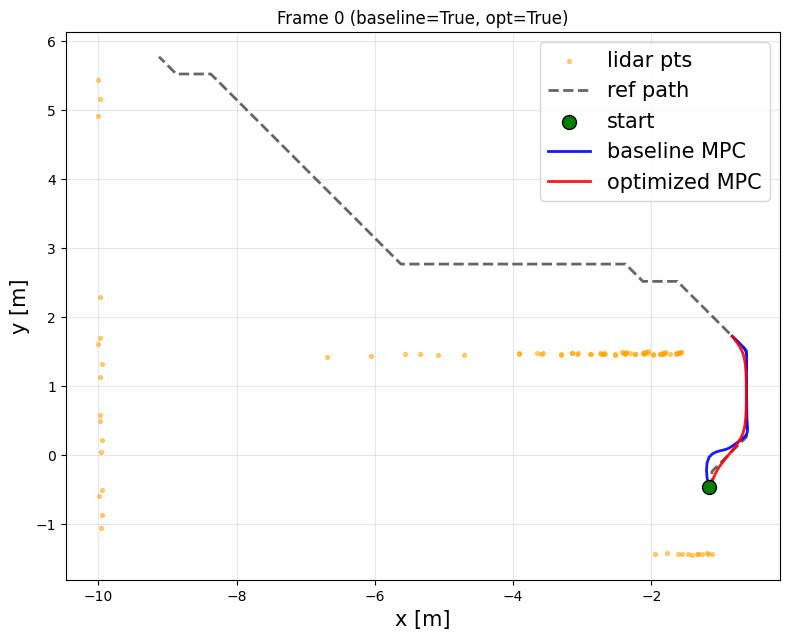

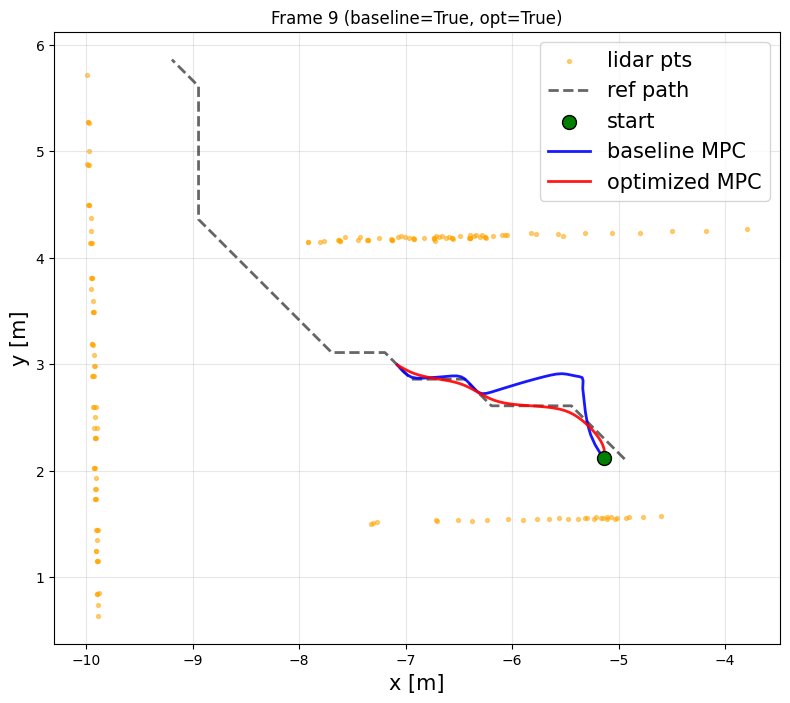

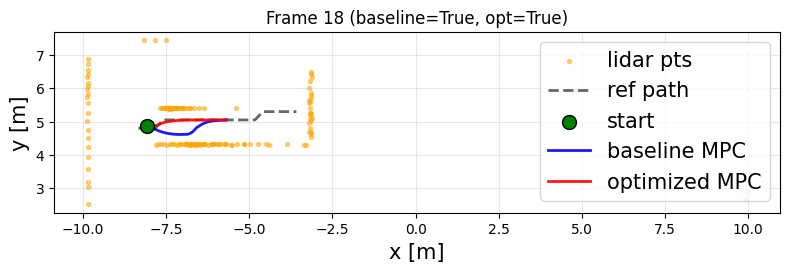

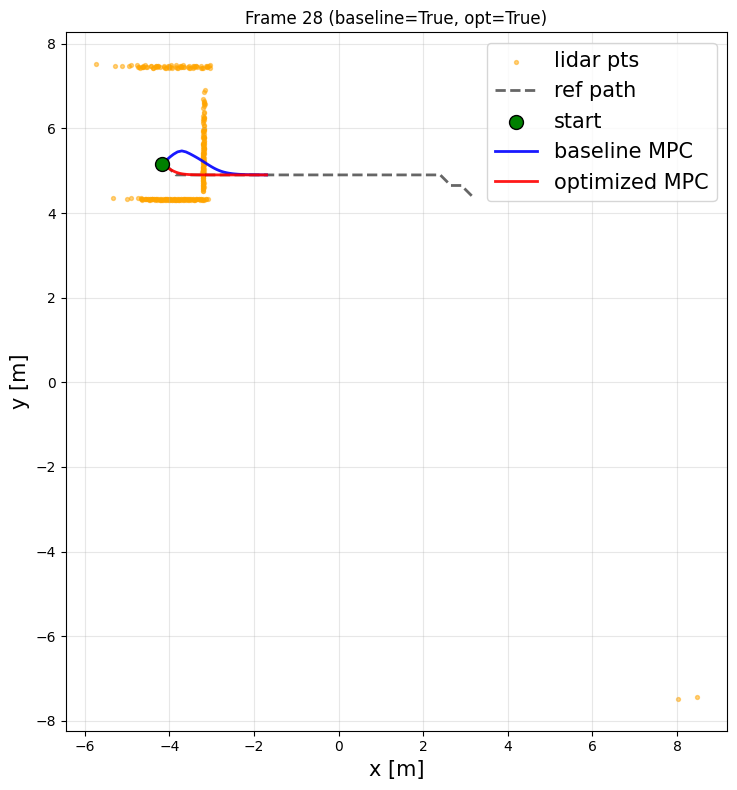

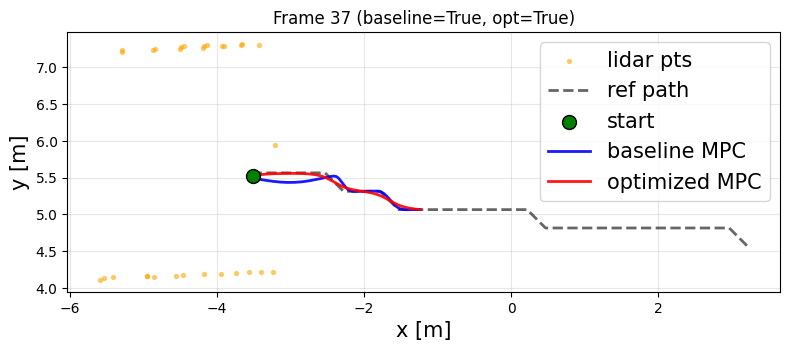

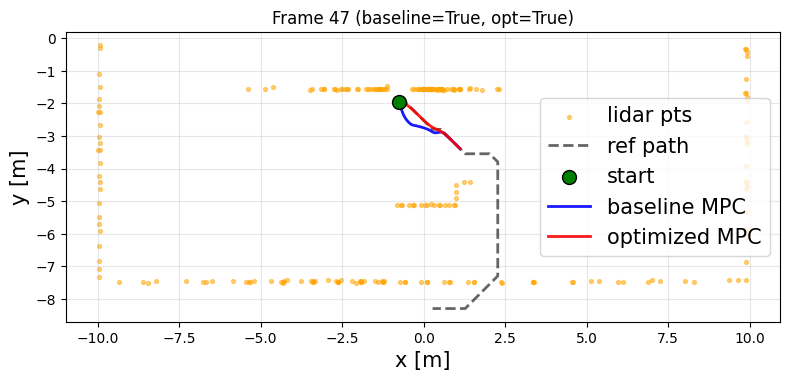

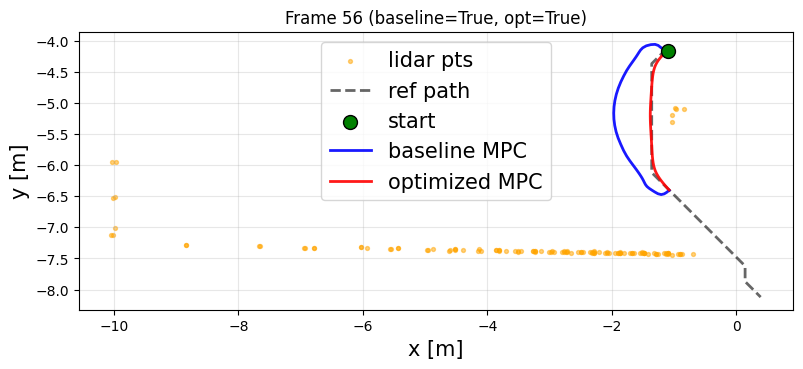

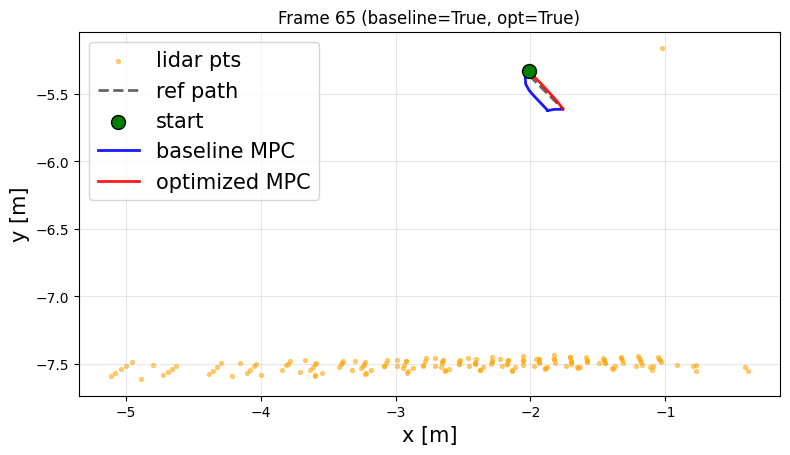

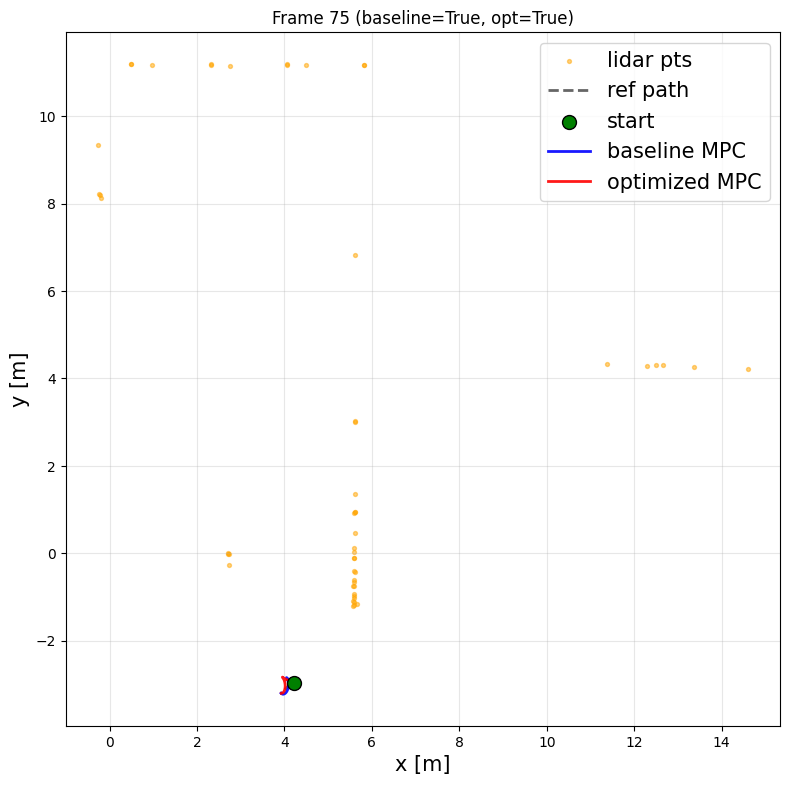

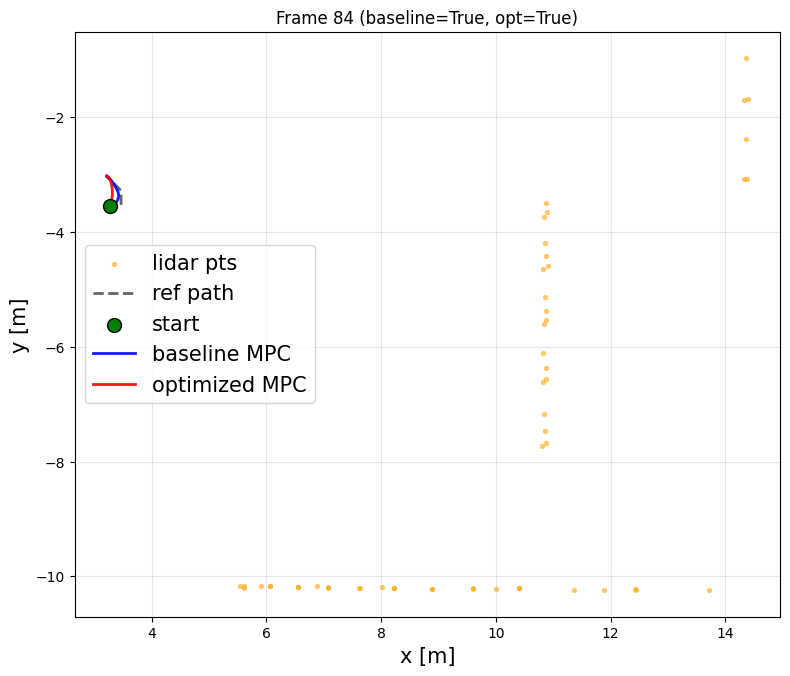

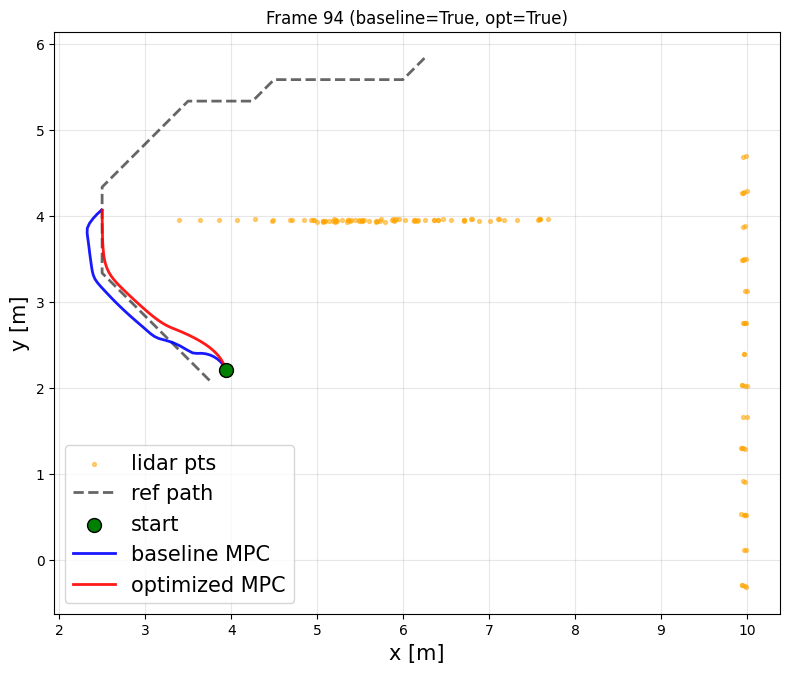

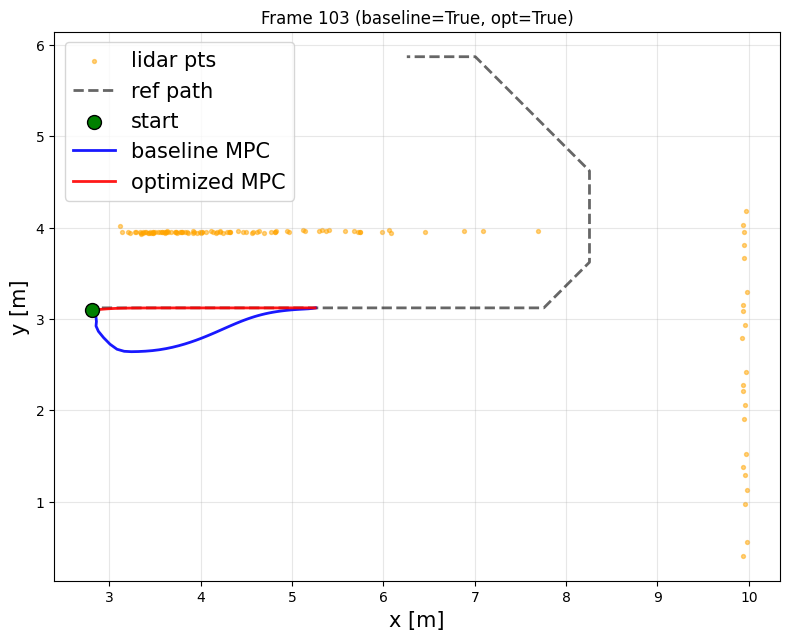

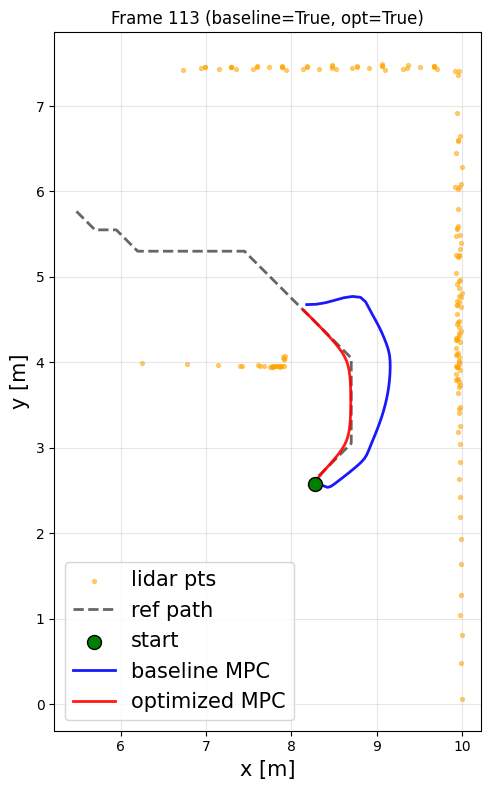

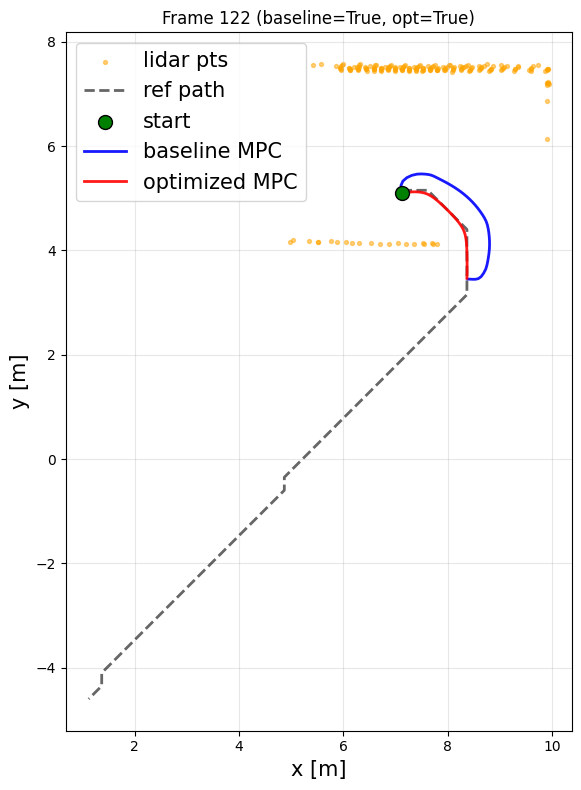

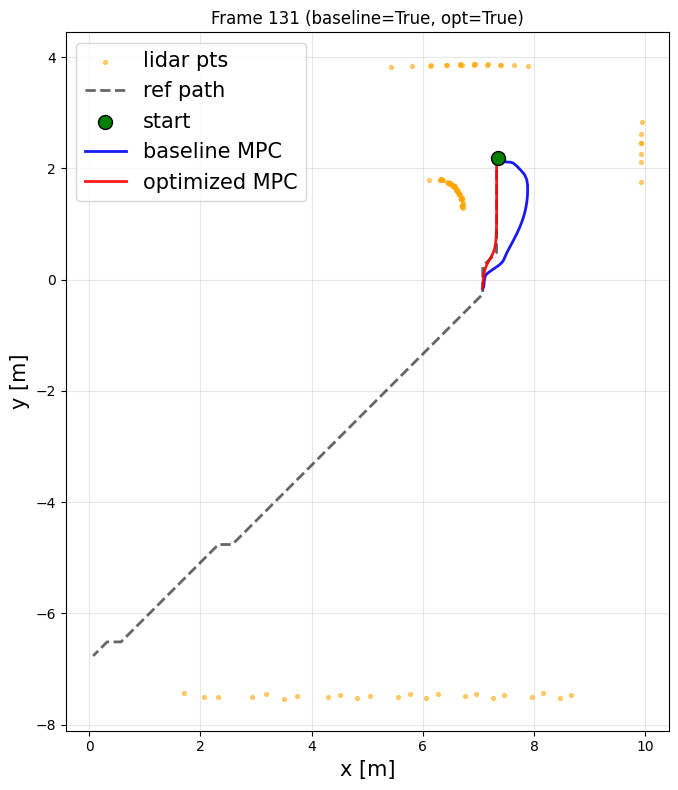

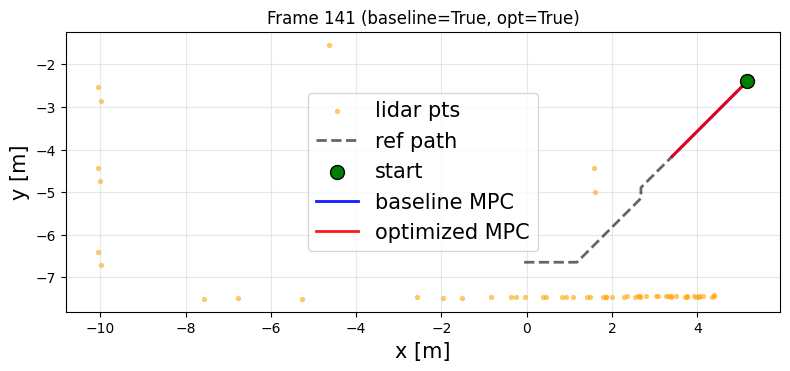

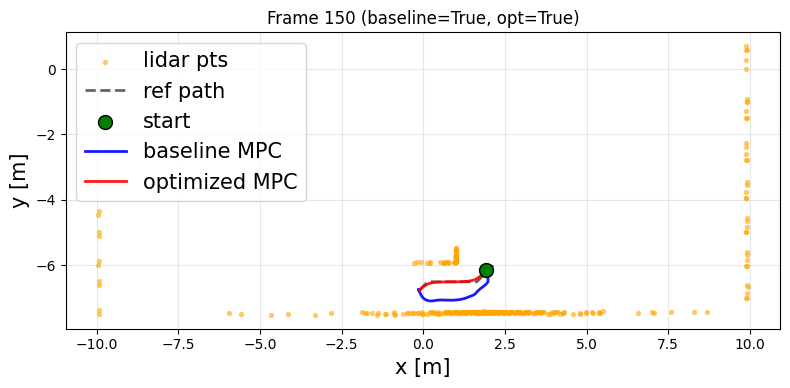

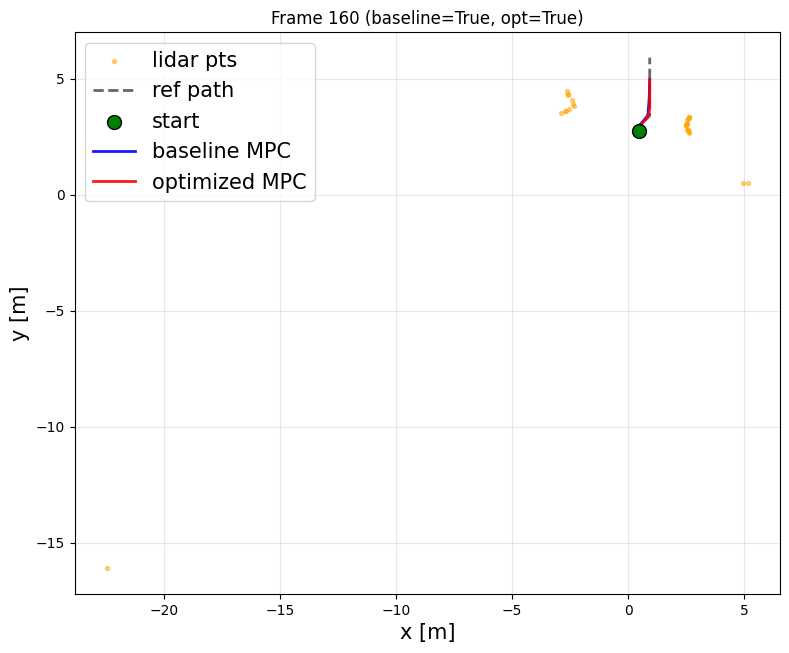

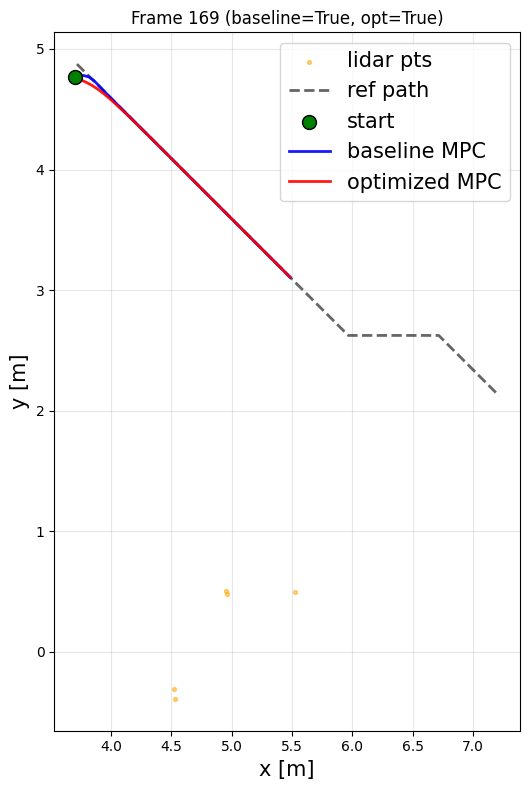

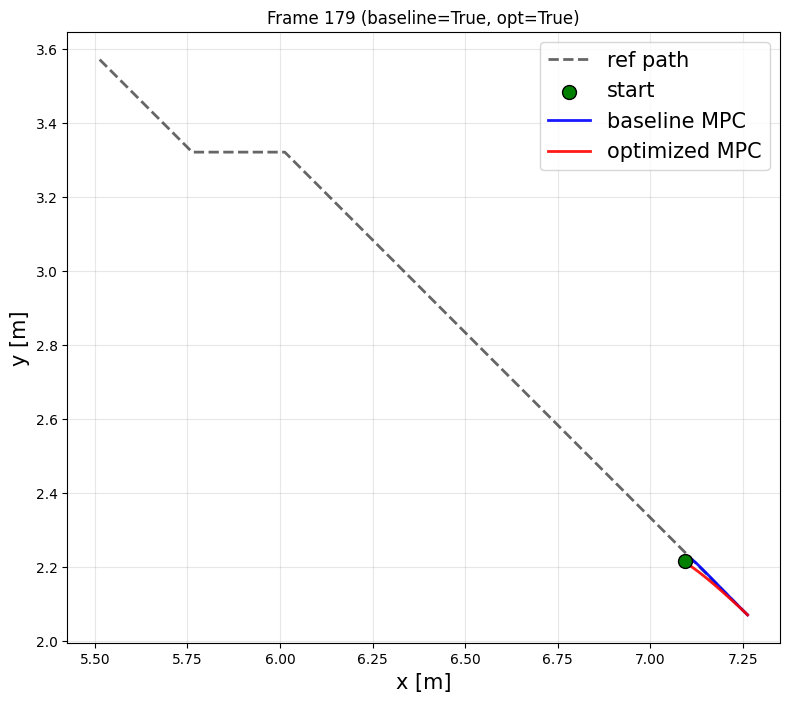

[GP-TUNE] Trajectory comparisons plotted with environment obstacles


In [ ]:
log_section('Baseline vs Optimized Trajectory Overlay')

# Plot each selected frame as a separate figure with its own legend
n_to_plot = min(30, len(traj_comps))
plot_indices = np.linspace(0, len(traj_comps) - 1, n_to_plot).astype(int)

for comp_idx in plot_indices:
    comp = traj_comps[comp_idx]
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Plot obstacles if available
    if world_obstacles is not None:
        for obs in world_obstacles:
            circle = plt.Circle((obs['x'], obs['y']), obs['r'], color='gray', alpha=0.3)
            ax.add_patch(circle)

    # Plot lidar points from bag
    obs_xy = comp.get('obs_xy')
    if obs_xy is not None and len(obs_xy) > 0:
        obs_arr = np.asarray(obs_xy)
        ax.scatter(obs_arr[:, 0], obs_arr[:, 1], c='orange', s=8, alpha=0.5, label='lidar pts')

    # Plot reference path
    path = comp.get('path')
    if path is not None and len(path) > 0:
        path_arr = np.asarray(path)
        if path_arr.ndim == 2 and path_arr.shape[1] >= 2:
            ax.plot(path_arr[:, 0], path_arr[:, 1], 'k--', lw=2, alpha=0.6, label='ref path')

    # Plot robot starting state
    state = comp['state']
    ax.scatter([state[0]], [state[1]], c='green', s=100, marker='o', edgecolors='black', linewidths=1, label='start', zorder=10)

    # Plot MPC trajectories
    if comp.get('traj_baseline') is not None:
        tb = np.asarray(comp['traj_baseline'])
        ax.plot(tb[:, 0], tb[:, 1], 'b-', lw=2, alpha=0.9, label='baseline MPC')

    if comp.get('traj_optimized') is not None:
        to = np.asarray(comp['traj_optimized'])
        ax.plot(to[:, 0], to[:, 1], 'r-', lw=2, alpha=0.9, label='optimized MPC')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Frame {comp["frame_idx"]} (baseline={comp["success_baseline"]}, opt={comp["success_optimized"]})')
    ax.set_xlabel('x [m]', fontsize=15)
    ax.set_ylabel('y [m]', fontsize=15)

    # show legend on each figure
    ax.legend(loc='best', fontsize=15)

    plt.tight_layout()

    if comp["frame_idx"] == 113:
        plt.savefig(out_dir / f'trajectory_comparison_frame_{comp["frame_idx"]}.pdf')
    plt.show()

log_step('Trajectory comparisons plotted with environment obstacles')


Trajectory statistics and aggregate comparison
[GP-TUNE] Trajectory statistics:
[GP-TUNE]   Baseline success rate: 100.0%
[GP-TUNE]   Optimized success rate: 100.0%
[GP-TUNE]   Baseline mean path length: 2.338 m
[GP-TUNE]   Optimized mean path length: 2.013 m


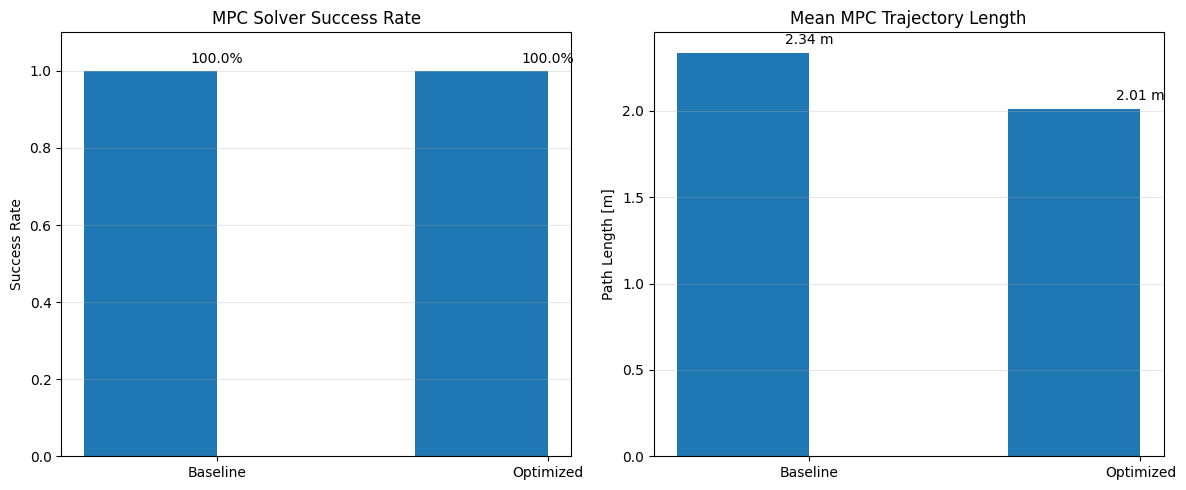

[GP-TUNE] Trajectory comparison plots complete


In [ ]:
log_section('Trajectory statistics and aggregate comparison')

# Compute trajectory statistics
stats = {'baseline_success': 0, 'optimized_success': 0, 'baseline_dist': [], 'optimized_dist': []}

for comp in traj_comps:
    if comp['success_baseline']:
        stats['baseline_success'] += 1
        if comp['traj_baseline'] is not None:
            dist = np.sum(np.linalg.norm(np.diff(comp['traj_baseline'], axis=0), axis=1))
            stats['baseline_dist'].append(dist)
    
    if comp['success_optimized']:
        stats['optimized_success'] += 1
        if comp['traj_optimized'] is not None:
            dist = np.sum(np.linalg.norm(np.diff(comp['traj_optimized'], axis=0), axis=1))
            stats['optimized_dist'].append(dist)

stats['baseline_success_rate'] = stats['baseline_success'] / len(traj_comps)
stats['optimized_success_rate'] = stats['optimized_success'] / len(traj_comps)
stats['baseline_mean_dist'] = np.mean(stats['baseline_dist']) if stats['baseline_dist'] else 0.0
stats['optimized_mean_dist'] = np.mean(stats['optimized_dist']) if stats['optimized_dist'] else 0.0

log_step('Trajectory statistics:')
log_step(f'  Baseline success rate: {stats["baseline_success_rate"]:.1%}')
log_step(f'  Optimized success rate: {stats["optimized_success_rate"]:.1%}')
log_step(f'  Baseline mean path length: {stats["baseline_mean_dist"]:.3f} m')
log_step(f'  Optimized mean path length: {stats["optimized_mean_dist"]:.3f} m')

# Comparison bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Success rates
ax = axes[0]
x = np.array([0, 1])
y = np.array([stats['baseline_success_rate'], stats['optimized_success_rate']])
ax.bar(x - 0.2, y, width=0.4, label='success rate')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Optimized'])
ax.set_ylabel('Success Rate')
ax.set_title('MPC Solver Success Rate')
ax.set_ylim([0, 1.1])
for i, v in enumerate(y):
    ax.text(x[i], v + 0.02, f'{v:.1%}', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Mean path length
ax = axes[1]
y_dist = np.array([stats['baseline_mean_dist'], stats['optimized_mean_dist']])
ax.bar(x - 0.2, y_dist, width=0.4, label='mean path length')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline', 'Optimized'])
ax.set_ylabel('Path Length [m]')
ax.set_title('Mean MPC Trajectory Length')
for i, v in enumerate(y_dist):
    ax.text(x[i], v + 0.05, f'{v:.2f} m', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

log_step('Trajectory comparison plots complete')

In [ ]:
# Plot the predicted mean and uncertainty for the best parameter set
best_x_n = scaler.transform(best_x.reshape(1, -1))
best_mu, best_std = gp_final.predict(best_x_n, return_std=True)
log_step(f'Best parameter set prediction: mean={best_mu[0]:.4f}, std={best_std[0]:.4f}')    



[GP-TUNE] Best parameter set prediction: mean=0.5948, std=0.1255


In [18]:
log_section('MPC diagnostics extraction and analysis')

DIAGNOSTICS_TOPIC = '/mpc/diagnostics'


def _is_scalar_like(v):
    return isinstance(v, (str, bool, int, float, np.integer, np.floating, np.bool_)) or v is None


def _flatten_value(value, prefix, out):
    """Recursively flatten ROS message-like objects into scalar fields."""
    if _is_scalar_like(value):
        out[prefix] = value
        return

    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            out[prefix] = value.item()
        elif value.size <= 8 and np.issubdtype(value.dtype, np.number):
            for i, vv in enumerate(value.tolist()):
                out[f'{prefix}[{i}]'] = vv
        return

    if isinstance(value, (list, tuple)):
        if len(value) == 0:
            return
        if all(_is_scalar_like(v) for v in value):
            if len(value) <= 8:
                for i, vv in enumerate(value):
                    out[f'{prefix}[{i}]'] = vv
            else:
                out[prefix] = list(value)
            return
        for i, vv in enumerate(value):
            _flatten_value(vv, f'{prefix}[{i}]', out)
        return

    slots = getattr(value, '__slots__', None)
    if slots:
        for name in slots:
            if name.startswith('_'):
                continue
            try:
                vv = getattr(value, name)
            except Exception:
                continue
            child_prefix = f'{prefix}.{name}' if prefix else name
            _flatten_value(vv, child_prefix, out)
        return

    # fallback: string representation for unknown objects
    if prefix:
        out[prefix] = str(value)


def _list_topics_in_db3(db3_path):
    con = sqlite3.connect(str(db3_path))
    cur = con.cursor()
    rows = cur.execute('SELECT name, type FROM topics ORDER BY name ASC').fetchall()
    con.close()
    return rows


# Load diagnostics messages from the inference bag set.
diagnostics_msgs = []
selected_topic = DIAGNOSTICS_TOPIC
for bag_path in combined_bag_files:
    diagnostics_msgs.extend(load_topic_messages(bag_path, selected_topic))

# Fallback: search for a diagnostics-like topic if /mpc/diagnostics is not present.
if len(diagnostics_msgs) == 0 and len(combined_bag_files) > 0:
    topic_rows = _list_topics_in_db3(combined_bag_files[0])
    candidate_topics = [name for name, _ in topic_rows if ('diag' in name.lower()) or ('mpc' in name.lower())]
    log_step(f'No messages found on {DIAGNOSTICS_TOPIC}; candidate topics: {candidate_topics}')
    for topic_name in candidate_topics:
        diagnostics_msgs = []
        for bag_path in combined_bag_files:
            diagnostics_msgs.extend(load_topic_messages(bag_path, topic_name))
        if len(diagnostics_msgs) > 0:
            selected_topic = topic_name
            break

assert len(diagnostics_msgs) > 0, f'No diagnostics messages found in the selected bags: {combined_bag_files}'
log_step(f'Using diagnostics topic: {selected_topic}')
log_step(f'Loaded {len(diagnostics_msgs)} diagnostics messages')

records = []
for t, msg in diagnostics_msgs:
    row = {'t': float(t)}
    _flatten_value(msg, '', row)
    # remove empty keys if any
    row = {k: v for k, v in row.items() if k != ''}
    records.append(row)

diag_df = pd.DataFrame(records)

# Keep only columns that are useful for analysis.
num_df = diag_df.select_dtypes(include=[np.number]).copy()
log_step(f'Diagnostics dataframe shape: {diag_df.shape}')
log_step(f'Numeric diagnostic fields: {list(num_df.columns)}')

# Heuristically identify the most useful metrics if they exist.
preferred_cols = [
    'solve_time_ms', 'solve_time', 'objective', 'cost', 'success', 'status',
    'iterations', 'iter', 'n_iter', 'n_constraints', 'active_constraints',
    'tracking_error', 'tracking_xy_error', 'yaw_error', 'path_error',
    'obstacle_distance', 'min_obstacle_distance', 'clearance',
    'u_vx', 'u_vy', 'u_omega', 'cmd_vx', 'cmd_vy', 'cmd_omega'
]
selected_cols = [c for c in preferred_cols if c in diag_df.columns]
if not selected_cols:
    selected_cols = [c for c in num_df.columns if c != 't'][:12]

log_step(f'Selected useful diagnostic fields: {selected_cols}')

# Basic summary table.
summary_cols = [c for c in selected_cols if c in num_df.columns]
if summary_cols:
    display(num_df[summary_cols].describe().T)

# Save flattened diagnostics for later reuse.
out_dir = REPO_ROOT / 'bag_gp_tuning' / 'diagnostics'
out_dir.mkdir(parents=True, exist_ok=True)
diag_csv = out_dir / 'mpc_diagnostics_flattened.csv'
diag_df.to_csv(diag_csv, index=False)
log_step(f'Saved flattened diagnostics to: {diag_csv}')

# Derive a few helpful aggregates.
fig_count = 0
plot_cols = [c for c in selected_cols if c in num_df.columns and c != 't']
if plot_cols:
    ncols = 2
    nrows = int(np.ceil(len(plot_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        series = num_df[col]
        if 'success' in col.lower() or series.dropna().isin([0, 1]).all():
            ax.plot(diag_df['t'], series.astype(float), label=col)
            ax.set_ylabel(col)
            ax.set_title(f'{col} over time')
            ax.grid(True, alpha=0.3)
            ax.set_ylim([-0.05, 1.05])
        else:
            ax.plot(diag_df['t'], series, label=col)
            ax.set_ylabel(col)
            ax.set_title(f'{col} over time')
            ax.grid(True, alpha=0.3)
        ax.set_xlabel('time [s]')
        ax.legend()

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    fig_count += 1

# If a success-like column exists, report success rate.
success_cols = [c for c in diag_df.columns if 'success' in c.lower() or c.lower() == 'status']
if success_cols:
    for c in success_cols:
        s = diag_df[c]
        if s.dropna().isin([0, 1]).all():
            log_step(f'{c}: success rate = {float(s.astype(float).mean()):.1%}')
        else:
            log_step(f'{c}: unique values = {sorted(pd.unique(s.dropna()))[:10]}')

# Correlation with solve time, if present.
solve_candidates = [c for c in num_df.columns if 'solve_time' in c.lower() or 'time' in c.lower()]
if solve_candidates:
    solve_col = solve_candidates[0]
    corr = num_df.corr(numeric_only=True)[solve_col].dropna().sort_values(key=lambda s: s.abs(), ascending=False)
    log_step(f'Top correlations with {solve_col}:')
    display(corr.head(12).to_frame(name='corr'))

log_step('Diagnostics extraction complete')


MPC diagnostics extraction and analysis
[GP-TUNE] Using diagnostics topic: /mpc/diagnostics
[GP-TUNE] Loaded 917 diagnostics messages
[GP-TUNE] Diagnostics dataframe shape: (917, 1)
[GP-TUNE] Numeric diagnostic fields: ['t']
[GP-TUNE] Selected useful diagnostic fields: []
[GP-TUNE] Saved flattened diagnostics to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/diagnostics/mpc_diagnostics_flattened.csv
[GP-TUNE] Diagnostics extraction complete



MPC cost components during inference
[GP-TUNE] Saved MPC cost components plot to: /media/lorenzo/writable/Go2_navigation/bag_gp_tuning/inference_mpc_cost_components.pdf


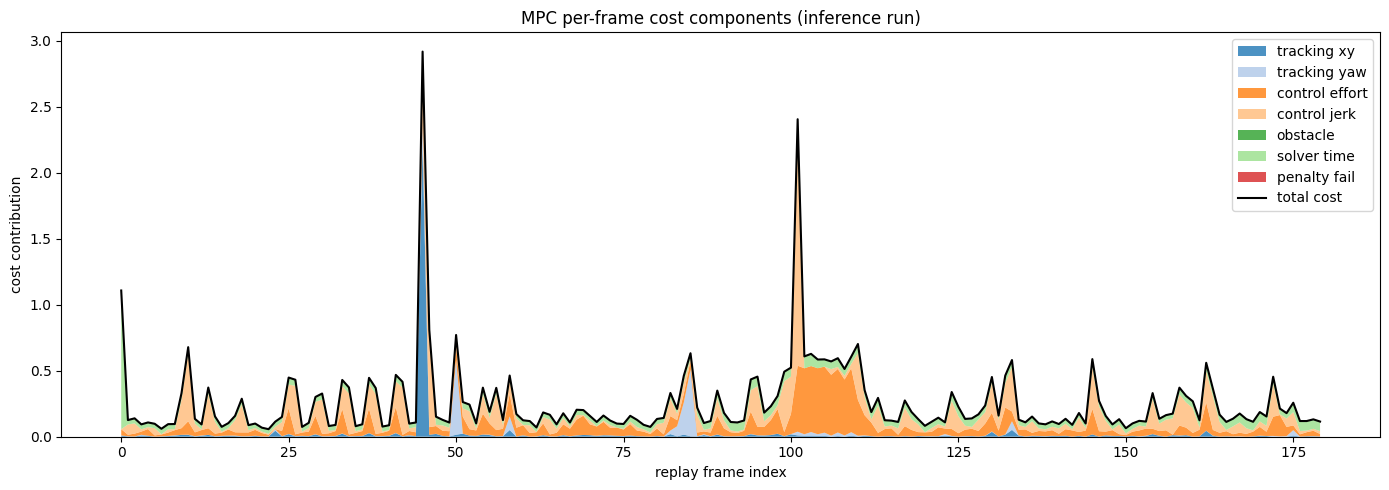

In [37]:
# Plot MPC cost components over inference replay frames
log_section('MPC cost components during inference')
# Ensure frames are present
if 'frames' not in globals() or not frames:
    log_step('Replay frames missing; rebuilding from bag messages')
    poses = load_and_concat(combined_bag_files, TOPIC_POSE)
    paths = load_and_concat(combined_bag_files, TOPIC_PATH)
    lidars = load_and_concat(combined_bag_files, TOPIC_LIDAR)
    frames = build_replay_frames(poses, paths, lidars, MAX_FRAMES, LIDAR_STRIDE, LIDAR_MAX_POINTS)
    log_step(f'Rebuilt frames: {len(frames)}')

# Determine parameter vector to evaluate (prefer optimized best_x, fall back to baseline x0)
if 'best_x' in globals():
    eval_x = best_x
elif 'saved_record' in globals() and 'best_params' in saved_record:
    eval_x = np.array([saved_record['best_params'][p] for p in PARAM_NAMES], dtype=np.float64)
else:
    eval_x = x0

# Compute detailed per-frame terms
det = evaluate_params_detailed(eval_x, frames, base_cfg)
series = det.get('series', {})
# if no series data, abort gracefully
if not series or all(len(v) == 0 for v in series.values()):
    log_step('No per-frame cost series available; skipping cost components plot')
else:
    n = len(next(iter(series.values())))
    idx = np.arange(n)

    # Components order for stacked plot
    components = ['tracking_xy','tracking_yaw','control_effort','control_jerk','obstacle','solver_time','penalty_fail']
    data = []
    for comp in components:
        arr = series.get(comp, None)
        if arr is None:
            arr = np.zeros(n, dtype=np.float64)
        else:
            arr = np.asarray(arr, dtype=np.float64)
            if arr.shape[0] > n:
                arr = arr[:n]
        data.append(arr)
    stack = np.vstack(data)

    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [c.replace('_', ' ') for c in components]
    # pick a colormap with enough distinct colors
    cmap = plt.get_cmap('tab20')
    colors = list(cmap.colors)
    if len(colors) < len(components):
        colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(components)))
    # stackplot expects a sequence of arrays matching components
    ax.stackplot(idx, stack, labels=labels, colors=colors[:len(components)], alpha=0.8)
    # plot total step cost on top
    step_total = series.get('step_total', None)
    if step_total is None:
        step_total = np.sum(stack, axis=0)
    else:
        step_total = np.asarray(step_total, dtype=np.float64)
    ax.plot(idx, step_total, 'k-', lw=1.5, label='total cost')
    ax.set_xlabel('replay frame index')
    ax.set_ylabel('cost contribution')
    ax.set_title('MPC per-frame cost components (inference run)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    # Save figure
    out_dir = REPO_ROOT / 'bag_gp_tuning'
    out_dir.mkdir(parents=True, exist_ok=True)
    fpath = out_dir / 'inference_mpc_cost_components.pdf'
    fig.savefig(fpath)
    log_step(f'Saved MPC cost components plot to: {fpath}')
    plt.show()

### 3. Performance Metrics Calculation from Bag Files

This section is dedicated to processing the ROS 2 bag files generated by the `run_metrics_collection.sh` script. We will extract the necessary data to compute the **Success Rate (SR)** and **Cross-Track Error (CE)** for each experimental run (a combination of a world and a method). The final results will be compiled into a pandas DataFrame, mirroring the structure of the performance table in the research paper.

In [19]:
!pip install rosbags

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 6.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 3.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rosbags]m4/5 [rosbags]aml]


In [31]:
import re
import math
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from rosbags.rosbag2 import Reader

# ---- rosbags deserialize compatibility (old + new versions) ----
try:
    from rosbags.serde import deserialize_cdr as cdr_deserialize
except Exception:
    from rosbags.typesys import Stores, get_typestore
    _store = get_typestore(getattr(Stores, 'LATEST', Stores.ROS2_HUMBLE))

    def cdr_deserialize(rawdata, msgtype):
        return _store.deserialize_cdr(rawdata, msgtype)

# Optional: if REPO_ROOT is not defined in previous notebook cells
try:
    REPO_ROOT
except NameError:
    REPO_ROOT = Path.cwd()

# ============= Utility Functions =============
def yaw_from_quat(q):
    siny = 2.0 * (q.w * q.z + q.x * q.y)
    cosy = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return math.atan2(siny, cosy)


def wrap_pi(a):
    return math.atan2(math.sin(a), math.cos(a))


def get_ros_messages(reader, topic_name):
    """Yield deserialized messages from a Reader for topic_name."""
    connections = [c for c in reader.connections if c.topic == topic_name]
    if not connections:
        return
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        try:
            msg = cdr_deserialize(rawdata, connection.msgtype)
            yield timestamp * 1e-9, msg
        except Exception as e:
            print(f"  Warning: Failed to deserialize message from {topic_name}: {e}")
            continue


def calculate_path_length(path_xy):
    if path_xy is None or len(path_xy) < 2:
        return np.nan
    arr = np.asarray(path_xy, dtype=float)
    d = np.linalg.norm(np.diff(arr, axis=0), axis=1)
    return float(np.sum(d))


def calculate_cte(robot_path, reference_points):
    """
    Mean nearest distance from executed trajectory to the union of replanned reference points.
    This is robust to rolling-horizon replanning and avoids using only the first /a_star/path.
    """
    if not robot_path or reference_points is None or len(reference_points) == 0:
        return np.nan

    rp = np.asarray(reference_points, dtype=float)
    traj = np.asarray(robot_path, dtype=float)

    # Remove duplicate reference points to reduce cost.
    rp = np.unique(np.round(rp, 3), axis=0)

    try:
        from scipy.spatial import cKDTree
        tree = cKDTree(rp)
        d, _ = tree.query(traj, k=1)
        return float(np.mean(d))
    except Exception:
        # Fallback without scipy
        errs = []
        for p in traj:
            d = np.linalg.norm(rp - p, axis=1)
            errs.append(float(np.min(d)))
        return float(np.mean(errs)) if errs else np.nan


def extract_goal_pose(reader, goal_topic, path_topic):
    """
    Prefer explicit /goal_pose (last command sent), fallback to last /a_star/path endpoint.
    """
    goal_msgs = list(get_ros_messages(reader, goal_topic))
    if goal_msgs:
        _, gm = goal_msgs[-1]
        q = gm.pose.orientation
        return [gm.pose.position.x, gm.pose.position.y, yaw_from_quat(q)], 'goal_pose'

    path_msgs = list(get_ros_messages(reader, path_topic))
    for _, path_msg in reversed(path_msgs):
        if path_msg.poses:
            last = path_msg.poses[-1].pose
            q = last.orientation
            return [last.position.x, last.position.y, yaw_from_quat(q)], 'path_endpoint'

    return None, 'missing'


def check_success(final_pose, goal_pose, tolerance_dist=0.5):
    """
    Match the online experiment criterion in run_metrics_collection.sh: distance-only success.
    """
    if final_pose is None or goal_pose is None:
        return False
    dist_error = np.linalg.norm(np.array(final_pose[:2]) - np.array(goal_pose[:2]))
    return dist_error <= tolerance_dist


def extract_robot_trajectory(reader):
    """Return timestamps and xy using /go2/pose if available, otherwise /odom."""
    pose_msgs = list(get_ros_messages(reader, '/go2/pose'))
    if pose_msgs:
        ts = []
        traj = []
        for t, m in pose_msgs:
            ts.append(float(t))
            traj.append([float(m.pose.position.x), float(m.pose.position.y)])
        q = pose_msgs[-1][1].pose.orientation
        final_pose = [traj[-1][0], traj[-1][1], yaw_from_quat(q)]
        return ts, traj, final_pose, '/go2/pose'

    odom_msgs = list(get_ros_messages(reader, '/odom'))
    if odom_msgs:
        ts = []
        traj = []
        for t, m in odom_msgs:
            ts.append(float(t))
            p = m.pose.pose.position
            traj.append([float(p.x), float(p.y)])
        q = odom_msgs[-1][1].pose.pose.orientation
        final_pose = [traj[-1][0], traj[-1][1], yaw_from_quat(q)]
        return ts, traj, final_pose, '/odom'

    return [], [], None, 'missing'


def extract_reference_points(reader, path_topic='/a_star/path', sample_step=2):
    """Collect points from ALL path replans to make CE robust."""
    path_msgs = list(get_ros_messages(reader, path_topic))
    if not path_msgs:
        return np.empty((0, 2), dtype=np.float64), 0

    ref = []
    for _, msg in path_msgs:
        pts = msg.poses
        if not pts:
            continue
        for i, p in enumerate(pts):
            if i % sample_step != 0:
                continue
            ref.append([float(p.pose.position.x), float(p.pose.position.y)])
    if not ref:
        return np.empty((0, 2), dtype=np.float64), len(path_msgs)
    return np.asarray(ref, dtype=np.float64), len(path_msgs)


def first_reach_time_sec(ts, traj, goal_xy, tol=0.5):
    if not ts or not traj or goal_xy is None:
        return np.nan
    t0 = ts[0]
    gx, gy = float(goal_xy[0]), float(goal_xy[1])
    for t, p in zip(ts, traj):
        if math.hypot(p[0] - gx, p[1] - gy) <= tol:
            return float(t - t0)
    return np.nan


# ============= Configuration =============
BAGS_ROOT = REPO_ROOT / 'bags_recordings'
metrics_dir = BAGS_ROOT / 'metrics_data'

TOPIC_PATH = '/a_star/path'
GOAL_TOPIC = '/goal_pose'
GOAL_TOL = 0.5

# ============= Discovery =============
# Accept both layouts:
# A) .../T1/bag/metadata.yaml + bag_0.db3
# B) .../T1/metadata.yaml + bag_0.db3
known_methods = ['baseline', 'bo_opti', 'bo_tuned', 'planner_params', 'copy_planner_params']
method_alias = {
    'bo_opti': 'bo_tuned',
    'planner_params': 'bo_tuned',
    'copy_planner_params': 'baseline',
}
world_alias = {
    'opne_world': 'open_world',
    'werehouse_env': 'warehouse',
}

run_items = []
for run_dir in sorted(metrics_dir.glob('*')):
    if not run_dir.is_dir():
        continue

    run_name = run_dir.name
    method = 'unknown'
    world = run_name
    for km in known_methods:
        if run_name.endswith(f'_{km}'):
            method = km
            world = run_name[:-len(f'_{km}')]
            break
    method = method_alias.get(method, method)
    world = world_alias.get(world.strip().lower(), world.strip().lower())

    for trial_dir in sorted(run_dir.glob('T*')):
        if not trial_dir.is_dir():
            continue
        m = re.match(r'T(\d+)', trial_dir.name)
        trial_idx = int(m.group(1)) if m else -1

        # layout A
        bag_dir_a = trial_dir / 'bag'
        if (bag_dir_a / 'metadata.yaml').exists() and any(bag_dir_a.glob('bag_*.db3')):
            run_items.append((world, method, trial_idx, bag_dir_a))
            continue

        # layout B
        if (trial_dir / 'metadata.yaml').exists() and any(trial_dir.glob('bag_*.db3')):
            run_items.append((world, method, trial_idx, trial_dir))
            continue

print(f'Found {len(run_items)} trial bags under: {metrics_dir}')

# ============= Processing =============
per_run = []
for world, method, trial_idx, bag_dir in run_items:
    bag_label = f'{world}/{method}/T{trial_idx}'

    try:
        with Reader(str(bag_dir)) as reader:
            ts, robot_path, final_pose, pose_source = extract_robot_trajectory(reader)
            goal_pose, goal_source = extract_goal_pose(reader, GOAL_TOPIC, TOPIC_PATH)
            ref_pts, n_path_msgs = extract_reference_points(reader, TOPIC_PATH, sample_step=2)

            success = check_success(final_pose, goal_pose, tolerance_dist=GOAL_TOL)
            cte = calculate_cte(robot_path, ref_pts)

            t_goal = first_reach_time_sec(ts, robot_path, goal_pose[:2] if goal_pose else None, tol=GOAL_TOL)
            path_len = calculate_path_length(robot_path)

            dist_final = np.nan
            if final_pose is not None and goal_pose is not None:
                dist_final = float(np.linalg.norm(np.array(final_pose[:2]) - np.array(goal_pose[:2])))

            per_run.append({
                'World': world,
                'Method': method,
                'Trial': trial_idx,
                'Success': int(success),
                'SR_run (%)': 100.0 if success else 0.0,
                'CE (m)': cte,
                'Time-to-goal (s)': t_goal,
                'Path length (m)': path_len,
                'Final dist to goal (m)': dist_final,
                'pose_source': pose_source,
                'goal_source': goal_source,
                'n_path_msgs': int(n_path_msgs),
                'n_ref_points': int(ref_pts.shape[0]),
                'bag_dir': str(bag_dir),
            })

    except Exception as e:
        print(f'Skipping {bag_label}: {e}')

per_run_df = pd.DataFrame(per_run)
if per_run_df.empty:
    print('No valid runs parsed. Check bag folders and topic availability.')
else:
    per_run_df = per_run_df.sort_values(['World', 'Method', 'Trial']).reset_index(drop=True)

    # Aggregate for paper table
    agg_rows = []
    for (world, method), g in per_run_df.groupby(['World', 'Method']):
        n = len(g)
        n_succ = int(g['Success'].sum())
        sr = 100.0 * n_succ / n if n > 0 else np.nan

        # CE on successful runs when available; fallback to all valid CE.
        ce_s = g.loc[(g['Success'] == 1) & g['CE (m)'].notna(), 'CE (m)']
        ce_a = g.loc[g['CE (m)'].notna(), 'CE (m)']
        ce_mean = float(ce_s.mean()) if len(ce_s) > 0 else (float(ce_a.mean()) if len(ce_a) > 0 else np.nan)

        tg_s = g.loc[(g['Success'] == 1) & g['Time-to-goal (s)'].notna(), 'Time-to-goal (s)']

        agg_rows.append({
            'World': world,
            'Method': method,
            'SR (%)': sr,
            'CE (m)': ce_mean,
            'Runs': n,
            'Successes': n_succ,
            'Time-to-goal mean (s)': float(tg_s.mean()) if len(tg_s) > 0 else np.nan,
            'Time-to-goal std (s)': float(tg_s.std()) if len(tg_s) > 1 else np.nan,
        })

    df_results = pd.DataFrame(agg_rows).sort_values(['World', 'Method']).reset_index(drop=True)

    print('\n--- Per-run metrics ---')
    display(per_run_df)

    print('\n--- Aggregated metrics (for paper table) ---')
    display(df_results)

    print('\n--- Pivot (SR / CE) ---')
    display(df_results.pivot(index='Method', columns='World', values=['SR (%)', 'CE (m)']))

    # Save for reproducibility
    out_dir = REPO_ROOT / 'bag_gp_tuning' / 'metrics_from_bags'
    out_dir.mkdir(parents=True, exist_ok=True)
    per_run_df.to_csv(out_dir / 'per_run_metrics.csv', index=False)
    df_results.to_csv(out_dir / 'aggregated_metrics.csv', index=False)
    print(f'Saved metrics CSVs to: {out_dir}')



[bag] goal_src=path_fallback dist=0.468, angle=2.184, success=False
[bag] goal_src=path_fallback dist=0.074, angle=0.699, success=False
[bag] goal_src=goal_pose dist=11.944, angle=2.312, success=False
[bag] goal_src=path_fallback dist=0.249, angle=1.137, success=False
[bag] goal_src=path_fallback dist=0.352, angle=0.794, success=False
[bag] goal_src=path_fallback dist=0.663, angle=0.962, success=False

--- Performance Metrics ---


,World,Method,SR (%),CE (m),Runs,Successes
0,indoor_office,bo_opti,0.0,NaN,2,0
1,open_world,baseline,0.0,NaN,2,0
2,open_world,bo_opti,0.0,NaN,2,0


SR (%)                   CE (m)           
World    indoor_office open_world indoor_office open_world
Method                                                    
baseline           NaN        0.0           NaN        NaN
bo_opti            0.0        0.0           NaN        NaN

In [30]:
if 'per_run_df' in globals() and len(per_run_df) > 0:
    print('Topic-source summary:')
    display(per_run_df[['World','Method','Trial','pose_source','goal_source','n_path_msgs','n_ref_points']])
else:
    print('Run the metrics extraction cell first.')



/media/lorenzo/writable/Go2_navigation/bags_recordings/metrics_data/opne_world_bo_opti/T2/bag goal: 0 pose: 781 path: 28


### 4. Odometry Trajectory Comparison Plots

The following cell generates plots to visually compare the odometry trajectories of the robot for the `baseline` and `bo_tuned` methods across the different test environments. Each plot corresponds to one world and overlays the paths taken for each method, allowing for a clear comparison of the navigation behavior.

/tmp/ipykernel_65769/3768941746.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


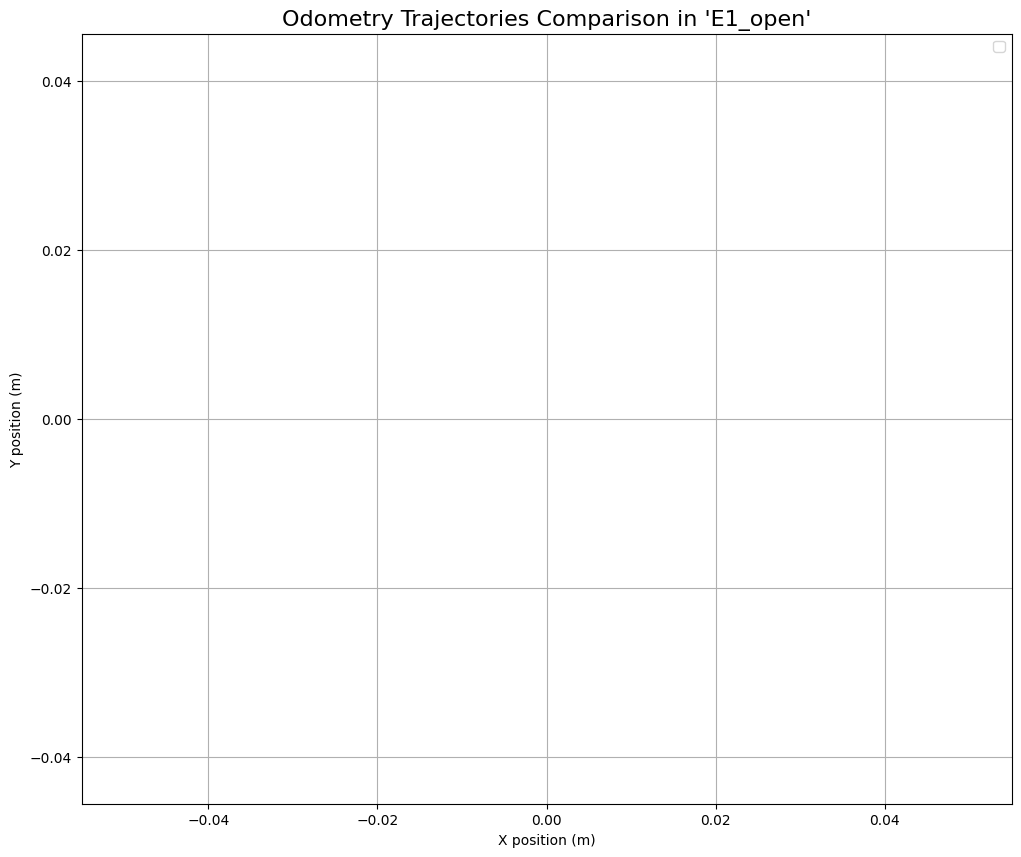

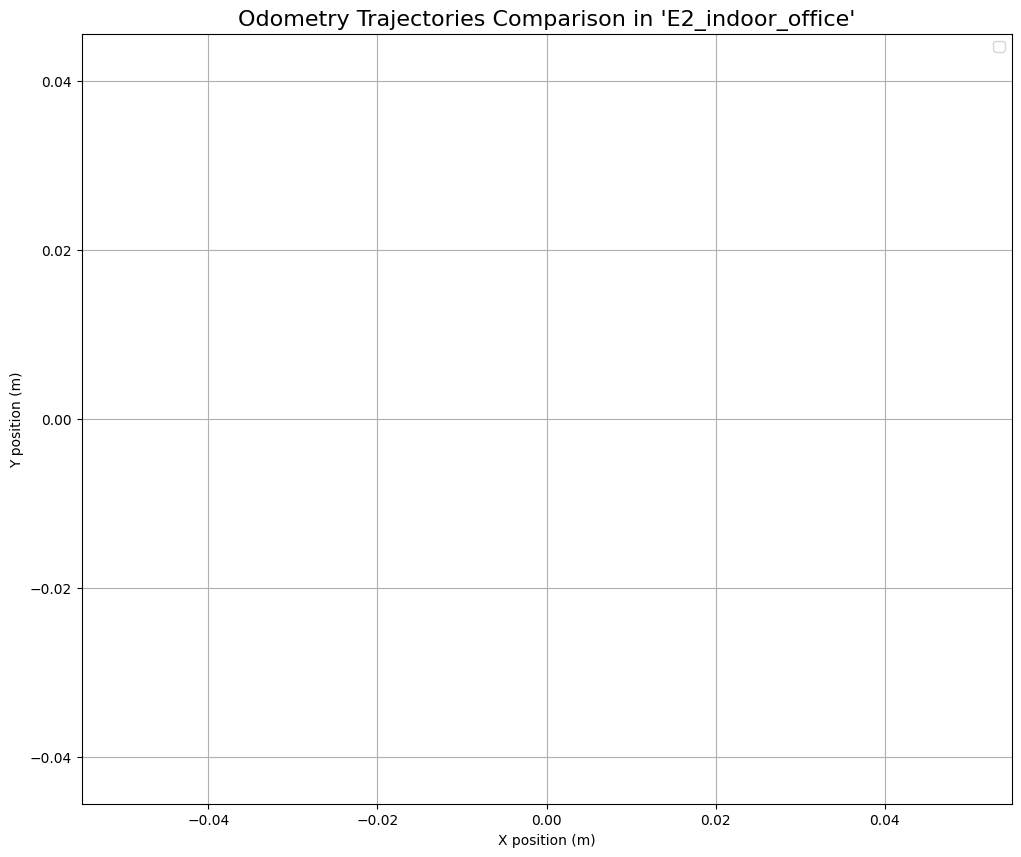

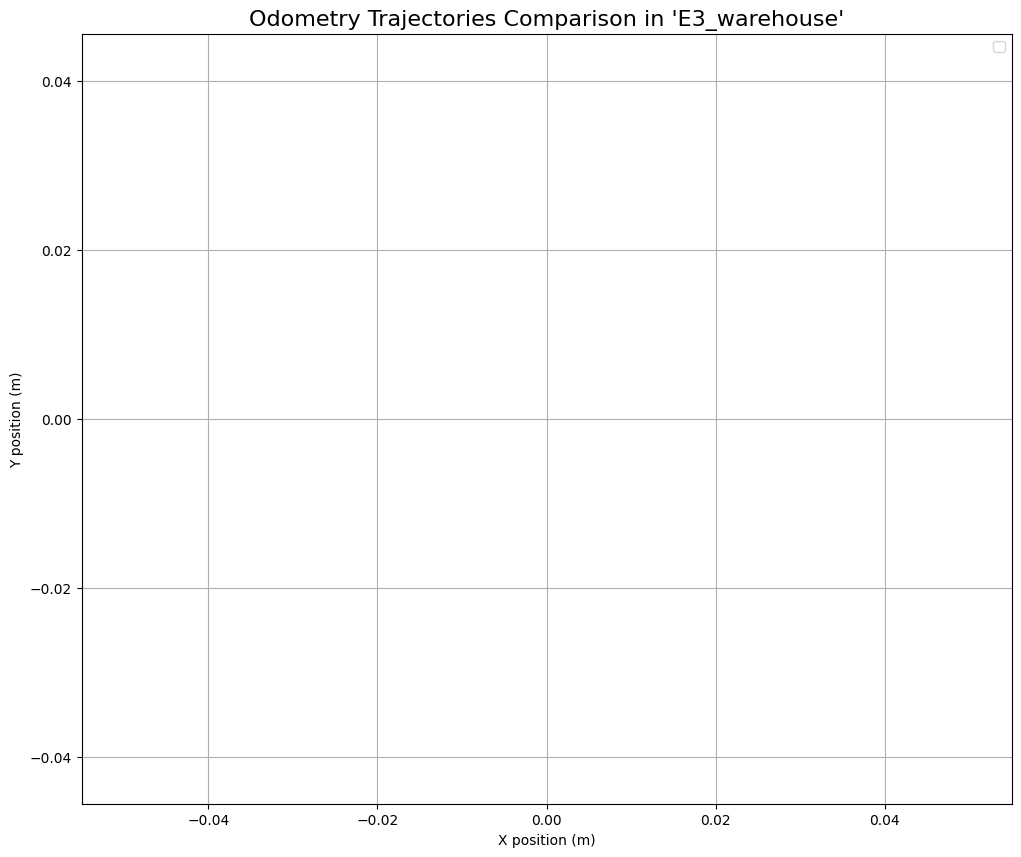

In [ ]:
import matplotlib.pyplot as plt

# Compare the same T1 task within each world using /odom trajectories.
BAG_BASE_DIR = REPO_ROOT / "bags_recordings" / "metrics_data"
TRIAL = "T1"
WORLDS = ["indoor_office", "open_world"]
METHODS = ["baseline", "bo_opti"]
world_alias = {"opne_world": "open_world"}


def find_trial_bag(world, method, trial=TRIAL):
    candidates = []
    for run_dir in sorted(BAG_BASE_DIR.glob(f"*_{method}")):
        run_world = run_dir.name[: -len(f"_{method}")]
        run_world = world_alias.get(run_world.strip().lower(), run_world.strip().lower())
        if run_world != world:
            continue

        bag_dir = run_dir / trial / "bag"
        if (bag_dir / "metadata.yaml").exists():
            candidates.append(bag_dir)

    return candidates[0] if candidates else None


def extract_odom_xy(reader):
    xs, ys = [], []
    for msg in get_ros_messages(reader, "/odom"):
        pos = msg.pose.pose.position
        xs.append(float(pos.x))
        ys.append(float(pos.y))
    return np.asarray(xs), np.asarray(ys)


def extract_last_path_xy(reader):
    path_msgs = list(get_ros_messages(reader, "/a_star/path"))
    for msg in reversed(path_msgs):
        if msg.poses:
            xs = [float(p.pose.position.x) for p in msg.poses]
            ys = [float(p.pose.position.y) for p in msg.poses]
            return np.asarray(xs), np.asarray(ys)
    return np.asarray([]), np.asarray([])


for world in WORLDS:
    fig, ax = plt.subplots(figsize=(10, 8))
    plotted = False
    reference_plotted = False

    for method in METHODS:
        bag_dir = find_trial_bag(world, method, TRIAL)
        if bag_dir is None:
            print(f"Missing {world} / {method} / {TRIAL}")
            continue

        with Reader(str(bag_dir)) as reader:
            odom_x, odom_y = extract_odom_xy(reader)
            path_x, path_y = extract_last_path_xy(reader)

        if odom_x.size == 0:
            print(f"No /odom messages in {bag_dir}")
            continue

        ax.plot(odom_x, odom_y, lw=2.5, label=f"{method} odom")
        ax.scatter(odom_x[0], odom_y[0], s=60, marker="o", label=f"{method} start")
        ax.scatter(odom_x[-1], odom_y[-1], s=80, marker="x", label=f"{method} final")
        plotted = True

        if not reference_plotted and path_x.size > 0:
            ax.plot(path_x, path_y, "k--", lw=2, alpha=0.7, label="T1 /a_star/path")
            ax.scatter(path_x[-1], path_y[-1], s=140, marker="*", c="red", label="path endpoint")
            reference_plotted = True

        print(
            f"{world}/{method}/{TRIAL}: bag={bag_dir}, "
            f"odom_msgs={odom_x.size}, path_points={path_x.size}, "
            f"start=({odom_x[0]:.2f}, {odom_y[0]:.2f}), "
            f"final=({odom_x[-1]:.2f}, {odom_y[-1]:.2f})"
        )

    if not plotted:
        plt.close(fig)
        print(f"No trajectories found for {world} {TRIAL}")
        continue

    ax.set_title(f"{world} {TRIAL}: /odom comparison by method", fontsize=15)
    ax.set_xlabel("X position [m]", fontsize=13)
    ax.set_ylabel("Y position [m]", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.axis("equal")
    ax.legend(loc="best", fontsize=10)
    plt.tight_layout()
    plt.show()


### 5. Direct Trajectory and Time-to-Goal Comparison

This section focuses on a head-to-head comparison for a single, challenging navigation task. We will load the bag files from the `direct_comparison` directory, calculate the time taken for each method to reach the goal, and plot their trajectories on the same graph to visually inspect the difference in path quality and efficiency.

In [ ]:
import seaborn as sns

# --- Configuration for Direct Comparison ---
COMPARISON_BAG_DIR = Path("../bags_recordings/direct_comparison")
COMPARISON_WORLD = "E3_warehouse"
METHODS = ["baseline", "bo_tuned"]
GOAL_TOLERANCE = 0.5 # meters

# --- Data Extraction and Plotting ---
plt.figure(figsize=(12, 10))
plt.title(f"Direct Trajectory Comparison in '{COMPARISON_WORLD}'", fontsize=16)

time_to_goal_results = {}
goal_pos = None

for method in METHODS:
    bag_dir = COMPARISON_BAG_DIR / f"{COMPARISON_WORLD}_{method}_comparison"
    if not bag_dir.exists():
        print(f"Warning: Comparison bag not found for method '{method}'. Skipping.")
        continue

    with Reader(bag_dir) as reader:
        # Get goal position (should be the same for both)
        if not goal_pos:
            goal_msg = next(get_ros_messages(reader, '/goal_pose'), None)
            if goal_msg:
                goal_pos = (goal_msg.pose.position.x, goal_msg.pose.position.y)

        # Extract trajectory and timestamps
        x_coords, y_coords, timestamps = [], [], []
        start_time = None
        
        connections = [c for c in reader.connections if c.topic == '/odom']
        if connections:
            for connection, timestamp, rawdata in reader.messages(connections=connections):
                if start_time is None:
                    start_time = timestamp
                
                msg = deserialize_cdr(rawdata, connection.msgtype)
                pos = msg.pose.pose.position
                x_coords.append(pos.x)
                y_coords.append(pos.y)
                timestamps.append((timestamp - start_time) / 1e9) # Convert to seconds

                # Check for goal arrival
                dist_to_goal = np.linalg.norm([pos.x - goal_pos[0], pos.y - goal_pos[1]])
                if dist_to_goal <= GOAL_TOLERANCE:
                    time_to_goal_results[method] = (timestamp - start_time) / 1e9
                    break # Stop processing once goal is reached

    # Plot trajectory
    plt.plot(x_coords, y_coords, label=f'{method} Trajectory', lw=2.5)

# --- Display Results ---
print("--- Time-to-Goal Comparison ---")
if time_to_goal_results:
    for method, ttg in time_to_goal_results.items():
        print(f"  Method '{method}': {ttg:.2f} seconds")
else:
    print("Could not calculate time-to-goal for one or both methods.")

# Plot markers
plt.plot(0, 0, 'go', markersize=12, label='Start')
if goal_pos:
    plt.plot(goal_pos[0], goal_pos[1], 'r*', markersize=15, label='Goal')

plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()